# Model Building

In [1]:

%load_ext autoreload
%autoreload 2


In [2]:
import torch 
import numpy as np
from torch.utils.data import  DataLoader, Subset
from sklearn.model_selection import KFold, train_test_split,StratifiedGroupKFold
from torchmetrics import Accuracy, Precision, Recall, F1Score,AUROC
import data_loading
from tqdm import tqdm
import itertools
import random
import pandas as pd

In [3]:
# check if there is GPU support 
if torch.cuda.is_available():
    print("CUDA is available! 🥳")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.get_device_name(0)}") # Check the name of the first GPU
else:
    print("CUDA is not available. 😟")


CUDA is available! 🥳
CUDA version: 12.6
Number of GPUs: 1
Current GPU: NVIDIA GeForce GTX 1650 Ti


In [4]:
random_seed_picked = 42
random_seed_picked

42

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [6]:
set_seed(random_seed_picked)

## 1. Data Loading

In [7]:
NLST_dataset = data_loading.NLSTDataset('final_preprocessed_datasets/lung_cancer_detection_segmented.h5','Lung_Cancer_multimodal_patient_EHR_categorical.csv',data_loading.train_transforms)

Loading Data....
Loading Done!


In [8]:
NLST_dataset_pid = NLST_dataset.get_all_pids()
NLST_dataset_pid.__len__()

14279

In [9]:
NLST_dataset_pid

[100012,
 100012,
 100012,
 100012,
 100012,
 100012,
 100012,
 100012,
 100012,
 100012,
 100012,
 100012,
 100012,
 100147,
 100147,
 100147,
 100147,
 100147,
 100147,
 100147,
 100147,
 100158,
 100158,
 100158,
 100158,
 100158,
 100158,
 100158,
 100242,
 100242,
 100242,
 100280,
 100280,
 100280,
 100280,
 100280,
 100280,
 100280,
 100280,
 100570,
 100570,
 100570,
 100570,
 100570,
 100570,
 100570,
 100570,
 100570,
 100658,
 100658,
 100658,
 100658,
 100658,
 100658,
 100658,
 100658,
 100658,
 100681,
 100681,
 100681,
 100681,
 100681,
 100697,
 100697,
 100697,
 100697,
 100697,
 100697,
 100703,
 100703,
 100703,
 100703,
 100703,
 100703,
 100703,
 100913,
 100913,
 100913,
 100913,
 100913,
 100954,
 100954,
 100954,
 100954,
 100954,
 100954,
 101066,
 101066,
 101066,
 101066,
 101066,
 101068,
 101068,
 101068,
 101068,
 101068,
 101192,
 101192,
 101192,
 101192,
 101192,
 101192,
 101192,
 101287,
 101287,
 101287,
 101287,
 101287,
 101287,
 101287,
 101287,
 

In [10]:
NLST_dataset.__len__()

14279

In [17]:
NLST_dataset[863]

({'image': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]]),
  'table': tensor([1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
          1.0000, 0.0000, 0.9474])},
 tensor(1))

In [12]:
for X_data,label in NLST_dataset[863]:
    print(X_data,label)
    

image table


TypeError: iteration over a 0-d tensor

In [24]:
X_data['table'].dtype

torch.float32

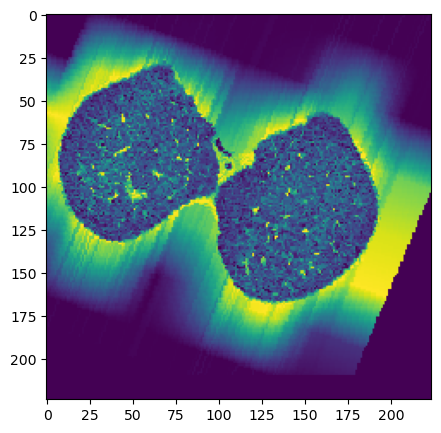

In [25]:
data_loading.print_dicomNM(X_data['image'][0],1,1,figsize=(5,5))

In [26]:
NLST_dataset_test = data_loading.NLSTDataset('final_preprocessed_datasets/lung_cancer_detection_segmented.h5','Lung_Cancer_multimodal_patient_EHR_categorical.csv')

Loading Data....
Loading Done!


In [27]:
for X_data,label in NLST_dataset_test:
    print(X_data,label)
    break

{'image': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), 'table': tensor([1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
        0.0000, 1.0000, 0.3158])} tensor(1)


In [28]:
for X_data,label in NLST_dataset_test:
    print(X_data,label)
    break

{'image': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), 'table': tensor([1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
        0.0000, 1.0000, 0.3158])} tensor(1)


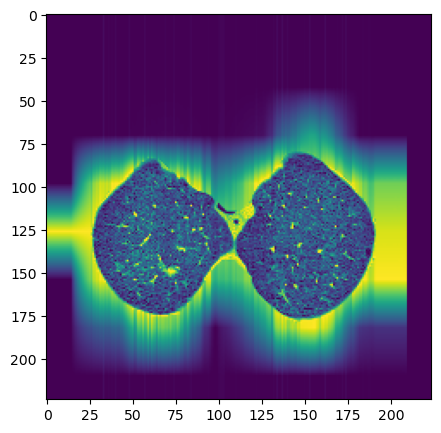

In [29]:
data_loading.print_dicomNM(X_data['image'][0],1,1,figsize=(5,5))

In [30]:
NLST_dataset.__len__()

14279

In [31]:
(NLST_dataset.__len__() / 10) / NLST_dataset.__len__()

0.1

In [32]:
lung_cancer_labels = np.load('final_preprocessed_datasets/lung_cancer_detection_labels.npy')

In [33]:
lung_cancer_labels

array([1, 1, 1, ..., 0, 0, 0])

In [34]:
NLST_dataloaders = DataLoader(NLST_dataset,batch_size=2,shuffle=True)

In [35]:
lung_cancer_labels.__len__()

14279

In [36]:
# test
for X_data,label in NLST_dataloaders:
    print(X_data,label)
    break

{'image': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]]), 'table': tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000,
         0.0000, 1.0000, 0.2105],
        [1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
         1.0000, 0.0000, 0.0000]])} tensor([1, 0])


In [37]:
X_data['table'].shape

torch.Size([2, 12])

In [38]:
X_data['image'][:].shape

torch.Size([2, 1, 224, 224])

Table Data: tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000,
         0.0000, 1.0000, 0.2105],
        [1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
         1.0000, 0.0000, 0.0000]])
Y_labels: tensor([1, 0])


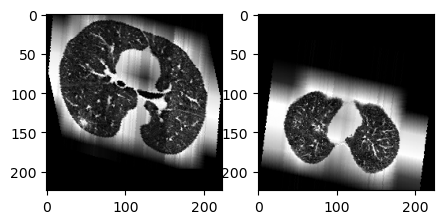

In [39]:
data_loading.print_dicomNM(X_data['image'],1,2,figsize=(5,5),nii_format=False)
print("Table Data:",X_data['table'])
print("Y_labels:",label)

In [40]:
indices = np.arange(len(NLST_dataset))
indices.__len__()

14279

In [41]:
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

In [42]:
for train_index, test_index in sgkf.split( X= indices, y= lung_cancer_labels, groups= NLST_dataset_pid):
    print("TRAIN:", train_index, "TEST:", test_index)
    print("TRAIN_Len:", train_index.__len__(), "TEST_Len:", test_index.__len__())  
    # Stop after the first iteration
    break

TRAIN: [    0     1     2 ... 14276 14277 14278] TEST: [   39    40    41 ... 14180 14181 14182]
TRAIN_Len: 12824 TEST_Len: 1455


In [43]:
1455/14279

0.10189789200924435

In [44]:
np_nlst_pid = np.array(NLST_dataset_pid)
np_nlst_pid[test_index]

array([100570, 100570, 100570, ..., 103737, 103737, 103737])

In [46]:
pd.DataFrame(lung_cancer_labels[test_index]).value_counts(normalize=True)

0
1    0.546392
0    0.453608
Name: proportion, dtype: float64

In [47]:
np_nlst_pid[train_index]

array([100012, 100012, 100012, ..., 103783, 103783, 103783])

In [48]:
np_nlst_pid[train_index].__len__()

12824

In [49]:
np_nlst_pid[train_index]

array([100012, 100012, 100012, ..., 103783, 103783, 103783])

In [50]:
np_nlst_pid[test_index][:100]

array([100570, 100570, 100570, 100570, 100570, 100570, 100570, 100570,
       100570, 100954, 100954, 100954, 100954, 100954, 100954, 101397,
       101397, 101397, 101397, 101397, 101397, 101397, 101397, 101397,
       101397, 101397, 101397, 101397, 102267, 102267, 102267, 102658,
       102658, 102658, 102658, 102658, 102658, 102658, 102658, 102658,
       103703, 103703, 103703, 103703, 103703, 103703, 103703, 103703,
       103703, 103703, 103703, 103703, 103703, 103703, 103703, 103703,
       103703, 103703, 103703, 103703, 103703, 103703, 103703, 103703,
       103703, 103703, 103703, 103703, 103703, 103703, 103703, 105165,
       105165, 105165, 105165, 107052, 107052, 107052, 107052, 107052,
       107052, 107052, 107052, 107052, 107052, 107052, 107052, 107052,
       107052, 107052, 107052, 107052, 107052, 108611, 108611, 108611,
       108611, 108611, 108611, 108611])

In [51]:
x_train = train_index
x_test = test_index
train_group = np_nlst_pid[train_index]
test_group = np_nlst_pid[test_index]
y_train = lung_cancer_labels[train_index]
y_test = lung_cancer_labels[test_index]

In [52]:
x_train.__len__() == train_group.__len__() == y_train.__len__()

True

In [53]:
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=random_seed_picked)
for fold, (train_idx_fold, val_idx_fold) in tqdm(enumerate(sgkf.split(X=x_train, y=y_train,groups=train_group)),desc="Kfold Iteration",total=10):
    print(f"Fold {fold}:")
    print(f"  Train indices length: {train_idx_fold.__len__()}")
    print(f"  Validation indices length: {val_idx_fold.__len__()}")
    # Stop after the first iteration for demonstration purposes
    if fold == 0:
        break

Kfold Iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Fold 0:
  Train indices length: 11594
  Validation indices length: 1230


## 2. Models

### 2.2 IMPROVED ENCODERS AND MULTIMODAL ATTENTION HEAD FOR INTERMEDIATE MULTIMODAL FUSION

In [41]:
import torch.nn as nn
from torchvision import models
from IPython.display import clear_output


#### 2.2.1 Pre train EHR Autoencoder

In [42]:
import pandas as pd
import numpy as np

In [43]:
Lung_cancer_EHR_training =pd.read_csv("Lung_Cancer_training_EHR_categorical.csv").iloc[:,1:-1].reset_index(drop=True)
Lung_cancer_EHR_training

,race_1,race_2,race_3,race_4,race_5,race_6,race_99,cigsmok_0,cigsmok_1,gender_1,gender_2,age
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.148148
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.148148
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.111111
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.259259
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.185185
...,...,...,...,...,...,...,...,...,...,...,...,...
32338,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.222222
32339,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.444444
32340,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.777778
32341,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.629630


In [44]:
Lung_cancer_Mulimodal = pd.read_csv("Lung_Cancer_multimodal_patient_EHR_categorical.csv").iloc[:,1:-1].reset_index(drop=True)
Lung_cancer_Mulimodal

,race_1,race_2,race_3,race_4,race_5,race_6,race_99,cigsmok_0,cigsmok_1,gender_1,gender_2,age
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.315789
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.684211
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.526316
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.263158
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.263158
...,...,...,...,...,...,...,...,...,...,...,...,...
1187,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.315789
1188,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.052632
1189,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.421053
1190,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.157895


In [121]:
class_weights = np.load("final_preprocessed_datasets/class_weights.npy")
class_weights.shape

(32343, 11)

In [122]:
class EHRDataset(torch.utils.data.Dataset):
    def __init__(self,tabular_data,weights):
        self.data = torch.tensor(tabular_data,dtype=torch.float32)
        self.weights = torch.tensor(weights,dtype=torch.float32)
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        weight = self.weights[idx]
        return item, weight

In [123]:
class EHRDeepAutoencoder(nn.Module):
    def __init__(self, input_dim=4, latent_dim=16):
        super(EHRDeepAutoencoder, self).__init__()
        
        # Encoder: 4 -> 16 -> 8 -> 2
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim) # The bottleneck
        )
        
        # Decoder: 2 -> 8 -> 16 -> 4
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
        )

        self.decoder_conversion = nn.Sequential(
            nn.ReLU(),
            nn.Linear(64, input_dim) # Output layer has no activation
        )

    def forward(self, x,feature_matrix = False):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        if feature_matrix:
            return decoded
        decoded = self.decoder_conversion(decoded)
        return decoded

In [124]:
batch_size = 1000
EHR_dataset = EHRDataset(Lung_cancer_EHR_training.to_numpy(),class_weights)
EHR_dataloader = DataLoader(EHR_dataset, batch_size=batch_size, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 4. Training Configuration ---
input_dim = Lung_cancer_EHR_training.shape[1] 
latent_dim = 16 # The size of our compressed representation
learning_rate = 0.001
num_epochs = 100

Using device: cuda


In [127]:
input_dim

12

In [128]:
EHR_model = EHRDeepAutoencoder(input_dim, latent_dim).to(device)
EHR_criterion_num = nn.MSELoss(reduction='none') # Mean Squared Error for reconstruction loss numerical
EHR_criterion_cat = nn.BCEWithLogitsLoss(reduction='none') # Mean Squared Error for reconstruction loss categorica
EHR_optimizer = torch.optim.Adam(EHR_model.parameters(), lr=learning_rate)

In [129]:
EHR_model

EHRDeepAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=12, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
  )
  (decoder_conversion): Sequential(
    (0): ReLU()
    (1): Linear(in_features=64, out_features=12, bias=True)
  )
)

In [130]:
EHR_model.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[ 0.1519, -0.1510, -0.1748,  0.2855, -0.0064,  0.2043, -0.2815, -0.1102,
                        0.2026, -0.0279,  0.0972, -0.2418],
                      [ 0.2810, -0.1441, -0.0146, -0.1891, -0.1281, -0.2475, -0.2527, -0.0590,
                       -0.1273,  0.2132, -0.0014,  0.2245],
                      [-0.0484,  0.0612,  0.2772, -0.2234, -0.1251,  0.2468, -0.0662, -0.0777,
                        0.0232, -0.1550,  0.0208, -0.1200],
                      [ 0.0916, -0.0613, -0.0969, -0.1087,  0.0750,  0.1449, -0.2639, -0.2013,
                       -0.2770,  0.1348,  0.2165, -0.2774],
                      [ 0.0750,  0.0585, -0.1549,  0.0624,  0.2226,  0.2832,  0.1248, -0.0572,
                       -0.1643, -0.1099,  0.0024, -0.0212],
                      [ 0.2106, -0.2609,  0.0258, -0.0918,  0.0241,  0.2776,  0.0084, -0.0501,
                       -0.0978, -0.2881, -0.2615,  0.1258],
                      [-0.1763,  0.1

In [131]:
for (X_data,weights) in EHR_dataloader:
    print(X_data.mean(dim=1))
    print(weights.shape)
    break

tensor([0.2685, 0.2778, 0.2809, 0.2932, 0.2840, 0.2778, 0.2840, 0.2901, 0.2593,
        0.3117, 0.2623, 0.2932, 0.2716, 0.3117, 0.2623, 0.2654, 0.2747, 0.2932,
        0.2593, 0.2654, 0.2623, 0.2840, 0.2901, 0.2685, 0.2932, 0.2809, 0.2994,
        0.2963, 0.2623, 0.2870, 0.2840, 0.2593, 0.2901, 0.2654, 0.2654, 0.2685,
        0.2623, 0.2654, 0.3086, 0.2654, 0.2870, 0.2840, 0.2778, 0.2654, 0.3117,
        0.2654, 0.2654, 0.2716, 0.2747, 0.2778, 0.2654, 0.3086, 0.2901, 0.2654,
        0.2654, 0.2623, 0.2593, 0.3148, 0.2623, 0.3025, 0.2593, 0.3086, 0.2593,
        0.3117, 0.2840, 0.2623, 0.2623, 0.2623, 0.2778, 0.2778, 0.3148, 0.2994,
        0.2716, 0.2716, 0.2840, 0.2809, 0.2870, 0.2747, 0.2654, 0.2623, 0.3117,
        0.2963, 0.2901, 0.2840, 0.2685, 0.2623, 0.2994, 0.2840, 0.2654, 0.2901,
        0.2685, 0.2963, 0.2901, 0.2716, 0.2623, 0.2747, 0.3117, 0.2932, 0.2623,
        0.2593, 0.2870, 0.2994, 0.2623, 0.2778, 0.2809, 0.2685, 0.2593, 0.2840,
        0.2623, 0.2747, 0.2840, 0.2778, 

In [132]:
# --- 5. The Training Loop ---
train_losses = []
train_loss_num = []
train_loss_cat = []
class_weights_tensor = torch.tensor(class_weights,dtype=torch.float32).to(device)
for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_loss_num = 0
    epoch_loss_cat = 0
    for (X_data,X_weights) in EHR_dataloader:
        batch = X_data.to(device)
        batch_weights = X_weights.to(device)
        # Forward pass
        reconstructed = EHR_model(batch)
        
        # Split the output and target for loss calculation
        recon_num = reconstructed[:,-1]
        recon_cat = reconstructed[:,:-1]
        
        target_num = batch[:, -1]
        target_cat = batch[:, :-1]
        
        # Calculate losses
        loss_num = EHR_criterion_num(recon_num, target_num)
        loss_cat = EHR_criterion_cat(recon_cat, target_cat)
        loss_cat_per_sample = (loss_cat * batch_weights).mean(dim=1) 
        # Combine the losses (you can add weights if one dominates)
        total_loss_per_sample = loss_num + loss_cat_per_sample
        

        final_loss = total_loss_per_sample.mean()
        
        
        epoch_loss += final_loss.item() 
        epoch_loss_num += loss_num.mean().item()
        epoch_loss_cat += loss_cat_per_sample.mean().item()

        
        # Backward and optimize
        EHR_optimizer.zero_grad()
        final_loss.backward()
        EHR_optimizer.step()
    avg_epoch_loss = epoch_loss / len(EHR_dataloader)
    avg_epoch_loss_num = epoch_loss_num / len(EHR_dataloader)
    avg_epoch_loss_cat = epoch_loss_cat / len(EHR_dataloader)
    train_losses.append(avg_epoch_loss)    
    train_loss_num.append(avg_epoch_loss_num)
    train_loss_cat.append(avg_epoch_loss_cat)   
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Total Loss: {avg_epoch_loss:.4f}, Num Loss: {avg_epoch_loss_num:.4f}, Cat Loss: {avg_epoch_loss_cat:.4f}')
        
print("Training complete.")


Epoch [10/100], Total Loss: 0.4646, Num Loss: 0.0311, Cat Loss: 0.4335
Epoch [20/100], Total Loss: 0.1599, Num Loss: 0.0153, Cat Loss: 0.1447
Epoch [30/100], Total Loss: 0.0124, Num Loss: 0.0029, Cat Loss: 0.0095
Epoch [40/100], Total Loss: 0.0040, Num Loss: 0.0012, Cat Loss: 0.0028
Epoch [50/100], Total Loss: 0.0024, Num Loss: 0.0011, Cat Loss: 0.0014
Epoch [60/100], Total Loss: 0.0012, Num Loss: 0.0005, Cat Loss: 0.0008
Epoch [70/100], Total Loss: 0.0013, Num Loss: 0.0008, Cat Loss: 0.0005
Epoch [80/100], Total Loss: 0.0005, Num Loss: 0.0002, Cat Loss: 0.0003
Epoch [90/100], Total Loss: 0.0004, Num Loss: 0.0001, Cat Loss: 0.0003
Epoch [100/100], Total Loss: 0.0009, Num Loss: 0.0007, Cat Loss: 0.0002
Training complete.


In [133]:
EHR_model.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[ 0.2904,  0.2414, -0.0509,  0.0372, -0.1812,  0.1489, -0.4021, -0.1301,
                        0.3998,  0.0740,  0.2438, -0.1797],
                      [ 0.4529, -0.3330, -0.1731, -0.5126, -0.5098, -0.2000, -0.5606,  0.0461,
                       -0.0327,  0.3707, -0.0088,  0.4586],
                      [ 0.0093,  0.2009, -0.0915,  0.0929, -0.0026,  0.6662,  0.2442, -0.3112,
                        0.4815,  0.1451,  0.1073,  0.0536],
                      [ 0.2450,  0.1481, -0.1359, -0.3580, -0.2608,  0.0293, -0.1956, -0.0392,
                       -0.2641,  0.2511,  0.2699, -0.1603],
                      [ 0.2419, -0.1482, -0.2264,  0.0128,  0.1675,  0.2169, -0.0744,  0.1934,
                       -0.3348, -0.2481,  0.3620,  0.1560],
                      [ 0.6755, -0.1957,  0.2756, -0.2230, -0.5411,  0.1782, -0.0382,  0.4045,
                        0.0741,  0.1729, -0.0835,  0.8070],
                      [-0.3541, -0.2

In [134]:
def revert_back(array,Logit_data =False):
    # 1)get items
    cat_data = array[:-1]
    num_data = array[-1]


    ## 2) Inverse transform the numerical part
    if isinstance(num_data, torch.Tensor):
        num_val = num_data.clone().detach().cpu().item()
    else:
        num_val = float(num_data)
    num_data_transformed = int(round(num_val * (79 - 52) + 52,0))



    # categorical probabilities: avoid torch.tensor(...) when cat_data is already a tensor
    if Logit_data:
        if isinstance(cat_data, torch.Tensor):
            cat_probs = torch.sigmoid(cat_data.clone().detach()).cpu().numpy()
        else:
            cat_probs = torch.sigmoid(torch.tensor(cat_data, dtype=torch.float32)).cpu().numpy()
    else:
        # already scores/probabilities -> convert to numpy
        if isinstance(cat_data, torch.Tensor):
            cat_probs = cat_data.clone().detach().cpu().numpy()
        else:
            cat_probs = np.array(cat_data, dtype=np.float32)


    start_idx = 0
    transformed_categories = []
    categorical_map = [
        {0:1,1:2,2:3,3:4,4:5,5:6,6:99},
        {0:0,1:1},
        {0:1,1:2} 
    ]
    for categories in categorical_map:
        # Get the relevant slice for this feature
        num_categories = len(categories)
        feature_slice = cat_probs[start_idx : start_idx + num_categories]
        # Find the index of the max probability
        max_idx = int(np.argmax(feature_slice, axis=0))
        # Set the corresponding element to 1
        transformed_categories.append(categories[max_idx])
        start_idx += num_categories
    transformed_categories.append(num_data_transformed)

    
    
    return transformed_categories

In [139]:
# --- 6. Evaluation and Visualization ---
EHR_model.eval() # Set the model to evaluation mode

# Take one sample from our dataset to test reconstruction
sample_idx = 67
original_sample = torch.Tensor(Lung_cancer_EHR_training.to_numpy()[sample_idx])# Add batch dimension


# Get the reconstruction from the model
with torch.no_grad():
    reconstructed_sample = EHR_model(original_sample.to(device))

# Move tensors to CPU and convert to numpy for display/plotting
original_np = revert_back(original_sample,Logit_data=False)


reconstructed_np = revert_back(reconstructed_sample,Logit_data=True)
print(original_np)
print(reconstructed_np)

[1, 0, 1, 70]
[1, 0, 1, 70]


In [140]:
torch.save(EHR_model,"multi_modal_models/EHR_self_trained.pt")

In [141]:
pretrained_vision_encoder = torch.load("multi_modal_models/EHR_self_trained.pt",weights_only=False)


In [142]:
pretrained_vision_encoder.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[ 0.2904,  0.2414, -0.0509,  0.0372, -0.1812,  0.1489, -0.4021, -0.1301,
                        0.3998,  0.0740,  0.2438, -0.1797],
                      [ 0.4529, -0.3330, -0.1731, -0.5126, -0.5098, -0.2000, -0.5606,  0.0461,
                       -0.0327,  0.3707, -0.0088,  0.4586],
                      [ 0.0093,  0.2009, -0.0915,  0.0929, -0.0026,  0.6662,  0.2442, -0.3112,
                        0.4815,  0.1451,  0.1073,  0.0536],
                      [ 0.2450,  0.1481, -0.1359, -0.3580, -0.2608,  0.0293, -0.1956, -0.0392,
                       -0.2641,  0.2511,  0.2699, -0.1603],
                      [ 0.2419, -0.1482, -0.2264,  0.0128,  0.1675,  0.2169, -0.0744,  0.1934,
                       -0.3348, -0.2481,  0.3620,  0.1560],
                      [ 0.6755, -0.1957,  0.2756, -0.2230, -0.5411,  0.1782, -0.0382,  0.4045,
                        0.0741,  0.1729, -0.0835,  0.8070],
                      [-0.3541, -0.2

In [143]:
# --- 7. Evaluation and Visualization for saved weights ---
pretrained_vision_encoder.eval() # Set the model to evaluation mode

# Take one sample from our dataset to test reconstruction
EHR_dataset_test = EHRDataset(Lung_cancer_Mulimodal.to_numpy()[:30],weights=class_weights[:30])
# Get the reconstruction from the model
with torch.no_grad():
    for (X_data,X_weight) in EHR_dataset_test:
        original_sample = X_data.to(device) # Add batch dimension
        reconstructed_sample = pretrained_vision_encoder(original_sample)
        original_np = revert_back(original_sample.cpu().numpy())
        reconstructed_np = revert_back(reconstructed_sample.cpu().numpy())
        print("original:",original_np,"reconstructed_adj:",reconstructed_np)


original: [1, 1, 2, 61] reconstructed_adj: [1, 1, 2, 61]
original: [1, 0, 1, 70] reconstructed_adj: [1, 0, 1, 71]
original: [1, 0, 1, 66] reconstructed_adj: [1, 0, 1, 66]
original: [1, 0, 2, 59] reconstructed_adj: [1, 0, 2, 59]
original: [1, 1, 2, 59] reconstructed_adj: [1, 1, 2, 59]
original: [1, 0, 1, 63] reconstructed_adj: [1, 0, 1, 64]
original: [1, 1, 1, 59] reconstructed_adj: [1, 1, 1, 59]
original: [1, 1, 1, 58] reconstructed_adj: [1, 1, 1, 58]
original: [1, 0, 1, 55] reconstructed_adj: [1, 0, 1, 55]
original: [1, 1, 1, 62] reconstructed_adj: [1, 1, 1, 62]
original: [1, 0, 1, 62] reconstructed_adj: [1, 0, 1, 62]
original: [1, 1, 2, 78] reconstructed_adj: [1, 1, 2, 78]
original: [1, 1, 2, 55] reconstructed_adj: [1, 1, 2, 55]
original: [1, 1, 1, 68] reconstructed_adj: [1, 1, 1, 68]
original: [1, 0, 2, 53] reconstructed_adj: [1, 0, 2, 55]
original: [1, 0, 2, 79] reconstructed_adj: [1, 0, 2, 79]
original: [2, 0, 2, 63] reconstructed_adj: [2, 0, 2, 63]
original: [1, 1, 2, 58] reconst

#### 2.2.2 Image Encoder

In [144]:
def get_resnet_model_for_1_channel(resnet_model,weights):
    """
    Loads a pre-trained ResNet-50, adapts its first layer for 1-channel
    (grayscale) input, and replaces the final classification layer.
    """
    # Load a pre-trained ResNet-50 model
    model = resnet_model(weights = weights)

    # --- MODIFICATION FOR 1-CHANNEL INPUT ---
    # 1. Get the original weights of the first convolutional layer
    original_weights = model.conv1.weight.clone()

    # 2. Create a new convolutional layer with 1 input channel
    new_conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    
    # 3. Adapt the pre-trained weights from 3 channels to 1
    # We do this by averaging the weights across the 3 RGB channels.
    with torch.no_grad():
        new_conv1.weight[:,:] = torch.sum(original_weights, dim=1, keepdim=True)

    # 4. Replace the original conv1 layer with the new one
    model.conv1 = new_conv1
    
    # --- END OF MODIFICATION ---
    


    # Replace the final classification layer for our specific task
    model.fc = nn.Identity()

    return model
    

In [158]:
IMG_model = get_resnet_model_for_1_channel(models.resnet34,weights=models.ResNet34_Weights.IMAGENET1K_V1)
IMG_model

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [159]:
EHR_model.decoder[2].out_features

64

In [160]:
IMG_model.layer4[2].bn2.num_features


512

#### 2.2.3 Multimodal Head

In [161]:
class MultimodalAttentionClassifier(nn.Module):
    def __init__(self, clinical_ehr_model, image_model, num_heads=4):
        super(MultimodalAttentionClassifier, self).__init__()
        
        # --- Feature Extractors ---
        self.clinical_model = clinical_ehr_model
        self.image_model = image_model
        clinical_encoding_dim = clinical_ehr_model.decoder[2].out_features
        image_feature_dim =[child for child in image_model.layer4[-1].children() if type(child) == torch.nn.modules.conv.Conv2d][-1].out_channels
        
        # --- Co-Attention Mechanism ---
        # Clinical data attends to image data
        self.img_attention = nn.MultiheadAttention(
            embed_dim=clinical_encoding_dim, 
            kdim=image_feature_dim, 
            vdim=image_feature_dim, 
            num_heads=num_heads, 
            batch_first=True # Makes handling batch dimensions easier
        )
        
        # Image data attends to clinical data
        self.clin_attention = nn.MultiheadAttention(
            embed_dim=image_feature_dim, 
            kdim=clinical_encoding_dim, 
            vdim=clinical_encoding_dim, 
            num_heads=num_heads, 
            batch_first=True
        )

        # --- Classifier Head ---
        # The input size is the sum of the two original feature dimensions
        fused_dim = clinical_encoding_dim + image_feature_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.Linear(fused_dim // 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 2),
              # 2 classes: cancer / no cancer 
        )

    def forward(self, clinical_data, image_data):
        # 1. Extract features from both modalities
        clinical_features = self.clinical_model(clinical_data,feature_matrix=True) # Shape: (batch_size, clinical_encoding_dim)
        
        image_features_raw = self.image_model(image_data)
        image_features = torch.flatten(image_features_raw, 1) # Shape: (batch_size, image_feature_dim)

        # 2. Reshape features for the attention layer (add a sequence dimension)
        clin_q = clinical_features.unsqueeze(1) # Shape: (batch_size, 1, clinical_encoding_dim)
        img_kv = image_features.unsqueeze(1)   # Shape: (batch_size, 1, image_feature_dim)
        
        img_q = image_features.unsqueeze(1)    # Shape: (batch_size, 1, image_feature_dim)
        clin_kv = clinical_features.unsqueeze(1) # Shape: (batch_size, 1, clinical_encoding_dim)

        # 3. Apply co-attention
        # Get image features weighted by clinical relevance
        attended_img, _ = self.img_attention(query=clin_q, key=img_kv, value=img_kv)
        
        # Get clinical features weighted by image relevance
        attended_clin, _ = self.clin_attention(query=img_q, key=clin_kv, value=clin_kv)

        # 4. Squeeze out the sequence dimension
        attended_img = attended_img.squeeze(1)
        attended_clin = attended_clin.squeeze(1)

        # 5. Concatenate the attended features and classify
        fused_features = torch.cat((attended_clin, attended_img), dim=1)
        output = self.classifier(fused_features)
        
        return output

### 2.3 FIRST INTERMEDIATE MODEL: Pretrained Self Made Autoencoder, Resnet32, Multiattention Head

In [162]:
best_f1 = -1
best_acc = -1
best_precision = -1
best_recall = -1
best_auroc = -1
best_params = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SPLITS = 10 # 10-fold CV for tuning

param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [50],
    'epochs': [10,15],
    'epsilon': [1e-8, 1e-7],
}


# --- 4. Hyperparameter Search with Inner CV Loop ---

# Create all combinations of hyperparameters
hyperparameter_combinations = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
len(hyperparameter_combinations)

8

In [152]:
hyperparameters_trained = list(np.load('hyperparameter_intermediate.npy',allow_pickle=True))
mean_f1_score_array = list(np.load('hyperparameter_intermediate_f1_score.npy'))

FileNotFoundError: [Errno 2] No such file or directory: 'hyperparameter_intermediate.npy'

In [153]:
hyperparameters_trained

NameError: name 'hyperparameters_trained' is not defined

In [ ]:
mean_f1_score_array

In [163]:
hyperparameters_trained = []
mean_f1_score_array = []

In [167]:
print("Starting Hyperparameter Tuning with Srtatified Group 10-Fold Cross-Validation...")

for params_index, params in enumerate(hyperparameter_combinations):
    current_lr = params['learning_rate']
    current_batch_size = params['batch_size']
    current_epoch_size = params['epochs']
    current_epsilon = params['epsilon']
    print(f""" Hyperparameter [{params_index+1}/{len(hyperparameter_combinations)}]
          \n--- Testing Params: LR={current_lr}, Batch_size = {current_batch_size} Epoch = {current_epoch_size} , Epsilon = {current_epsilon} ---
          """)
    
    k_fold_mean_f1 = []
    k_fold_mean_acc = []
    k_fold_mean_precision = []
    k_fold_mean_recall = []
    k_fold_mean_auroc = []
    total_f1_mean = 0
    total_acc_mean = 0
    total_precision_mean = 0
    total_recall_mean = 0
    total_auroc_mean = 0
    if params in hyperparameters_trained:
        k_fold_mean_f1 = mean_f1_score_array[params_index]
        # Check if these params are the best so far
        if k_fold_mean_f1 > best_f1:
            best_f1 = k_fold_mean_f1
            best_params = params
        print(f"Parameter Average F1-Score across {N_SPLITS} folds: {k_fold_mean_f1:.4f}\nParameters: {params}")
        continue



    # The CV splitter will operate *only* on the train_val_idx
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed_picked)
    for fold, (train_idx_fold, val_idx_fold) in tqdm(enumerate(sgkf.split(X=x_train, y=y_train,groups=train_group)),desc="Kfold Iteration",total=10):
        # Get the actual dataset indices for this fold
        train_subset = Subset(NLST_dataset, train_idx_fold)
        val_subset = Subset(NLST_dataset_test, val_idx_fold)
        train_loader = DataLoader(train_subset, batch_size=current_batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=current_batch_size)
        EHR_model = torch.load("multi_modal_models/EHR_self_trained.pt",weights_only=False).to(DEVICE)
        Image_model = get_resnet_model_for_1_channel(resnet_model=models.resnet34,weights=models.ResNet34_Weights.IMAGENET1K_V1).to(DEVICE)


        model = MultimodalAttentionClassifier(EHR_model,Image_model).to(DEVICE)
   
        optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr,eps=current_epsilon)

        criterion = nn.CrossEntropyLoss() # You can still use weighted loss here if needed

        # Training loop for the fold
        for epoch in range(current_epoch_size):
            model.train()
            total_loss = 0.0
            total_samples = 0
            for batch_data, batch_labels in train_loader:
                image_data = batch_data['image'].to(DEVICE)
                table_data = batch_data['table'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                outputs = model(table_data,image_data)
                
                
                batch_labels = batch_labels.to(DEVICE)
                loss = criterion(outputs, batch_labels)
                total_loss += loss.item() * batch_labels.size(0)
                total_samples += batch_labels.size(0)
                

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f"Epoch Stats {epoch+1} : Loss {total_loss / total_samples}")

            
            # Validation for the fold
        model.eval()
        acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
        precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)



        with torch.no_grad():
            for batch_data, batch_labels in val_loader:
                image_data = batch_data['image'].to(DEVICE)
                table_data = batch_data['table'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                
                outputs = model(table_data,image_data)
                pred = torch.softmax(outputs, dim=1)
                pred_labels = torch.argmax(pred, dim=1)

                acc_fn.update(pred_labels, batch_labels)
                precision_fn.update(pred_labels, batch_labels)
                recall_fn.update(pred_labels, batch_labels)
                f1_fn.update(pred_labels, batch_labels)
                auroc_fn.update(pred,batch_labels)

        # Average the F1 score across all folds for the current hyperparameter set
        mean_f1 = f1_fn.compute().cpu()
        mean_acc = acc_fn.compute().cpu()
        mean_precision = precision_fn.compute().cpu()
        mean_recall = recall_fn.compute().cpu()
        mean_auroc = auroc_fn.compute().cpu()
        clear_output(wait=True)
        k_fold_mean_f1.append(mean_f1)
        k_fold_mean_acc.append(mean_acc)
        k_fold_mean_precision.append(mean_precision)
        k_fold_mean_recall.append(mean_recall)
        k_fold_mean_auroc.append(mean_auroc)
        print(f"Average F1-Score across {fold+1}/{N_SPLITS} Stats: F1: {mean_f1:.4f} Acc: {mean_acc:.4f} Precision: {mean_precision:.4f} Recall: {mean_recall:.4f} AUROC: {mean_auroc:.4f}")
        f1_fn.reset()
        acc_fn.reset()
        precision_fn.reset()
        recall_fn.reset()
        auroc_fn.reset()

    # Check if these params are the best so far
    hyperparameters_trained.append(params)
    total_f1_mean = sum(k_fold_mean_f1) / N_SPLITS
    total_acc_mean = sum(k_fold_mean_acc) / N_SPLITS
    total_precision_mean = sum(k_fold_mean_precision) / N_SPLITS
    total_recall_mean = sum(k_fold_mean_recall) / N_SPLITS
    total_auroc_mean = sum(k_fold_mean_auroc) / N_SPLITS
    mean_f1_score_array.append(total_f1_mean)
    print(f"Parameter Average F1-Score across {N_SPLITS} Statistics: F1: {total_f1_mean:.4f} Acc: {total_acc_mean:.4f} Precision: {total_precision_mean:.4f} Recall: {total_recall_mean:.4f} AUROC: {total_auroc_mean:.4f}\nParameters: {params}")
    np.save('hyperparameter_intermediate_f1_score.npy',mean_f1_score_array)
    np.save('hyperparameter_intermediate.npy',hyperparameters_trained,allow_pickle=True)
    if total_f1_mean > best_f1:
        best_f1 = total_f1_mean
        best_acc = total_acc_mean
        best_precision = total_precision_mean
        best_recall = total_recall_mean
        best_auroc = total_auroc_mean
        best_params = params
        print(f"🎉 New best params found! 🎉",best_params)


    
print("\n===== Hyperparameter Tuning Complete =====")
print(f"Best Weighted F1-Score on Validation: F1: {best_f1:.4f} Acc: {best_acc:.4f} Precision: {best_precision:.4f} Recall: {best_recall:.4f} AUROC: {best_auroc:.4f}")
print(f"Best Hyperparameters: {best_params}")


Kfold Iteration: 100%|██████████| 10/10 [4:15:31<00:00, 1533.18s/it]

Average F1-Score across 10/10 Stats: F1: 0.9480 Acc: 0.9483 Precision: 0.9497 Recall: 0.9483 AUROC: 0.9832
Parameter Average F1-Score across 10 Statistics: F1: 0.8947 Acc: 0.8946 Precision: 0.8991 Recall: 0.8946 AUROC: 0.9598
Parameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}
🎉 New best params found! 🎉 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

===== Hyperparameter Tuning Complete =====
Best Weighted F1-Score on Validation: F1: 0.8947 Acc: 0.8946 Precision: 0.8991 Recall: 0.8946 AUROC: 0.9598
Best Hyperparameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}


Average F1-Score across 10/10 Stats: F1: 0.9480 Acc: 0.9483 Precision: 0.9497 Recall: 0.9483 AUROC: 0.9832
Parameter Average F1-Score across 10 Statistics: F1: 0.8947 Acc: 0.8946 Precision: 0.8991 Recall: 0.8946 AUROC: 0.9598
Parameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}
🎉 New best params found! 🎉 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

===== Hyperparameter Tuning Complete =====
Best Weighted F1-Score on Validation: F1: 0.8947 Acc: 0.8946 Precision: 0.8991 Recall: 0.8946 AUROC: 0.9598
Best Hyperparameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

In [ ]:
best_params

In [ ]:
best_params 


In [168]:
# --- 5. Final Training on All Train+Val Data ---
print("\n--- Training final model on the entire Train+Val set with best params ---")

final_lr = best_params['learning_rate']
final_batch_size = best_params['batch_size']
final_epoch_size = best_params['epochs']
final_epsilon = best_params['epsilon']
# Create datasets for the final train and test sets
final_train_dataset = Subset(NLST_dataset, x_train)
test_dataset = Subset(NLST_dataset_test, x_test)

final_train_loader = DataLoader(final_train_dataset, batch_size=final_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

# Initialize the final model
EHR_model = torch.load("multi_modal_models/EHR_self_trained.pt",weights_only=False).to(DEVICE)
Image_model = get_resnet_model_for_1_channel(resnet_model=models.resnet34,weights=models.ResNet34_Weights.IMAGENET1K_V1).to(DEVICE)
final_model = MultimodalAttentionClassifier(EHR_model,Image_model).to(DEVICE)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_lr,eps=final_epsilon)
criterion = nn.CrossEntropyLoss() # Again, can use weighted loss

# Train for a final number of epochs
loss_arr = []
for epoch in range(final_epoch_size): # You might train for more epochs here
    total_loss = 0.0
    total_samples = 0
    final_model.train()
    for batch_data, batch_labels in tqdm(final_train_loader,desc="Train Loader",total=len(final_train_loader)):
        image_data = batch_data['image'].to(DEVICE)
        table_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)


        outputs = final_model(table_data,image_data)
        loss = criterion(outputs, batch_labels)
        total_loss += loss.item() * batch_labels.size(0)
        total_samples += batch_labels.size(0)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Final training epoch {epoch+1}/{final_epoch_size}, : Loss: {total_loss / total_samples}")

# --- 6. Final Evaluation on the Held-Out Test Set ---
print("\n===== Evaluating on the Held-Out Test Set =====")
final_model.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image'].to(DEVICE)
        table_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)
        outputs = final_model(table_data,image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute().cpu()
total_precision = precision_fn.compute().cpu()
total_recall = recall_fn.compute().cpu()
total_f1 = f1_fn.compute().cpu()
total_auroc = auroc_fn.compute().cpu()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 


--- Training final model on the entire Train+Val set with best params ---


Train Loader: 100%|██████████| 257/257 [01:57<00:00,  2.18it/s]


Final training epoch 1/15, : Loss: 0.5540876307397504


Train Loader: 100%|██████████| 257/257 [01:56<00:00,  2.21it/s]


Final training epoch 2/15, : Loss: 0.36897372967765174


...

Final training epoch 14/15, : Loss: 0.18914911127576625


Train Loader: 100%|██████████| 257/257 [01:52<00:00,  2.28it/s]


Final training epoch 15/15, : Loss: 0.1808894717384941

===== Evaluating on the Held-Out Test Set =====


Test Loader: 100%|██████████| 1455/1455 [00:31<00:00, 45.96it/s]


Final Test Metrics:
  Accuracy:  0.8715
  Precision: 0.8907
  Recall:    0.8715
  F1-Score:  0.8713
  ROC-AUC:   0.9413


In [169]:
final_model.state_dict()

OrderedDict([('clinical_model.encoder.0.weight',
              tensor([[ 0.2598,  0.2243,  0.0124,  0.0673, -0.1657,  0.1092, -0.3531, -0.1540,
                        0.3982,  0.0319,  0.2775, -0.1933],
                      [ 0.4292, -0.3398, -0.1677, -0.5097, -0.4709, -0.2573, -0.5583,  0.0220,
                       -0.0610,  0.3328, -0.0196,  0.4208],
                      [ 0.0183,  0.1318, -0.1029,  0.1115, -0.0063,  0.7097,  0.1787, -0.2976,
                        0.4749,  0.1443,  0.1190,  0.1184],
                      [ 0.2265,  0.1737, -0.0970, -0.3414, -0.2714, -0.0106, -0.1289, -0.0519,
                       -0.2629,  0.2280,  0.2826, -0.2216],
                      [ 0.2194, -0.1164, -0.2307,  0.0260,  0.1563,  0.1567, -0.0101,  0.1693,
                       -0.3375, -0.2672,  0.3488,  0.1745],
                      [ 0.6439, -0.1998,  0.3002, -0.2153, -0.5290,  0.1311,  0.0258,  0.3854,
                        0.0795,  0.1392, -0.0567,  0.8238],
                     

In [170]:
np.save("multi_modal_models/Resnet34xDenoisexMultiattention_param.npy",best_params)

In [171]:
torch.save(final_model.cpu(),f='multi_modal_models/Resnet34xDenoiseModel.pt')

In [172]:
best_params = np.load("multi_modal_models/Resnet34xDenoisexMultiattention_param.npy",allow_pickle=True)
best_params

array({'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07},
      dtype=object)

In [173]:
Resnet34xDenoiseModel = torch.load('multi_modal_models/Resnet34xDenoiseModel.pt',weights_only=False)

In [174]:
Resnet34xDenoiseModel.state_dict()

OrderedDict([('clinical_model.encoder.0.weight',
              tensor([[ 0.2598,  0.2243,  0.0124,  0.0673, -0.1657,  0.1092, -0.3531, -0.1540,
                        0.3982,  0.0319,  0.2775, -0.1933],
                      [ 0.4292, -0.3398, -0.1677, -0.5097, -0.4709, -0.2573, -0.5583,  0.0220,
                       -0.0610,  0.3328, -0.0196,  0.4208],
                      [ 0.0183,  0.1318, -0.1029,  0.1115, -0.0063,  0.7097,  0.1787, -0.2976,
                        0.4749,  0.1443,  0.1190,  0.1184],
                      [ 0.2265,  0.1737, -0.0970, -0.3414, -0.2714, -0.0106, -0.1289, -0.0519,
                       -0.2629,  0.2280,  0.2826, -0.2216],
                      [ 0.2194, -0.1164, -0.2307,  0.0260,  0.1563,  0.1567, -0.0101,  0.1693,
                       -0.3375, -0.2672,  0.3488,  0.1745],
                      [ 0.6439, -0.1998,  0.3002, -0.2153, -0.5290,  0.1311,  0.0258,  0.3854,
                        0.0795,  0.1392, -0.0567,  0.8238],
                     

In [175]:
test_dataset = Subset(NLST_dataset_test, x_test)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

Resnet34xDenoiseModel.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted')
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted')
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted')
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted')
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted')
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image']
        table_data = batch_data['table']
        batch_labels = batch_labels
        outputs = Resnet34xDenoiseModel(table_data,image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute()
total_precision = precision_fn.compute()
total_recall = recall_fn.compute()
total_f1 = f1_fn.compute()
total_auroc = auroc_fn.compute()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 

Test Loader: 100%|██████████| 1455/1455 [01:29<00:00, 16.28it/s]

Final Test Metrics:
  Accuracy:  0.8715
  Precision: 0.8907
  Recall:    0.8715
  F1-Score:  0.8713
  ROC-AUC:   0.9413


#### 2.4 Second INTERMEDIATE MODEL: Pretrained Self Made Autoencoder, Resnet18, Multiattention Head

In [176]:
best_f1 = -1
best_acc = -1
best_precision = -1
best_recall = -1
best_auroc = -1
best_params = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SPLITS = 10 # 10-fold CV for tuning

param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [50],
    'epochs': [10,15],
    'epsilon': [1e-8, 1e-7],
}


# --- 4. Hyperparameter Search with Inner CV Loop ---

# Create all combinations of hyperparameters
hyperparameter_combinations = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
len(hyperparameter_combinations)

8

In [177]:
hyperparameters_trained = list(np.load('hyperparameter_intermediate_2.npy',allow_pickle=True))
mean_f1_score_array = list(np.load('hyperparameter_intermediate_f1_score_2.npy'))

FileNotFoundError: [Errno 2] No such file or directory: 'hyperparameter_intermediate_2.npy'

In [ ]:
hyperparameters_trained

In [ ]:
mean_f1_score_array

In [178]:
# run if restart needed
hyperparameters_trained = []
mean_f1_score_array = []

In [179]:
print("Starting Hyperparameter Tuning with 10-Fold Cross-Validation...")

for params_index, params in enumerate(hyperparameter_combinations):
    current_lr = params['learning_rate']
    current_batch_size = params['batch_size']
    current_epoch_size = params['epochs']
    current_epsilon = params['epsilon']
    print(f""" Hyperparameter [{params_index+1}/{len(hyperparameter_combinations)}]
          \n--- Testing Params: LR={current_lr}, Batch_size = {current_batch_size} Epoch = {current_epoch_size} , Epsilon = {current_epsilon} ---
          """)
    
    k_fold_mean_f1 = []
    k_fold_mean_acc = []
    k_fold_mean_precision = []
    k_fold_mean_recall = []
    k_fold_mean_auroc = []
    total_f1_mean = 0
    total_acc_mean = 0
    total_precision_mean = 0
    total_recall_mean = 0
    total_auroc_mean = 0
    if params in hyperparameters_trained:
        k_fold_mean_f1 = mean_f1_score_array[params_index]
        # Check if these params are the best so far
        if k_fold_mean_f1 > best_f1:
            best_f1 = k_fold_mean_f1
            best_params = params
        print(f"Parameter Average F1-Score across {N_SPLITS} folds: {k_fold_mean_f1:.4f}\nParameters: {params}")
        continue



    # The CV splitter will operate *only* on the train_val_idx
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed_picked)
    for fold, (train_idx_fold, val_idx_fold) in tqdm(enumerate(sgkf.split(X=x_train, y=y_train,groups=train_group)),desc="Kfold Iteration",total=10):
        # Get the actual dataset indices for this fold
        train_subset = Subset(NLST_dataset, train_idx_fold)
        val_subset = Subset(NLST_dataset_test, val_idx_fold)
        train_loader = DataLoader(train_subset, batch_size=current_batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=current_batch_size)
        EHR_model = torch.load("multi_modal_models/EHR_self_trained.pt",weights_only=False).to(DEVICE)
        Image_model = get_resnet_model_for_1_channel(resnet_model=models.resnet18,weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)


        model = MultimodalAttentionClassifier(EHR_model,Image_model).to(DEVICE)
   
        optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr,eps=current_epsilon)

        criterion = nn.CrossEntropyLoss() # You can still use weighted loss here if needed

        # Training loop for the fold
        for epoch in range(current_epoch_size):
            model.train()
            total_loss = 0.0
            total_samples = 0
            for batch_data, batch_labels in train_loader:
                image_data = batch_data['image'].to(DEVICE)
                table_data = batch_data['table'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                outputs = model(table_data,image_data)
                
                
                batch_labels = batch_labels.to(DEVICE)
                loss = criterion(outputs, batch_labels)
                total_loss += loss.item() * batch_labels.size(0)
                total_samples += batch_labels.size(0)
                

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f"Epoch Stats {epoch+1} : Loss {total_loss / total_samples}")

            
            # Validation for the fold
        model.eval()
        acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
        precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)



        with torch.no_grad():
            for batch_data, batch_labels in val_loader:
                image_data = batch_data['image'].to(DEVICE)
                table_data = batch_data['table'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                
                outputs = model(table_data,image_data)
                pred = torch.softmax(outputs, dim=1)
                pred_labels = torch.argmax(pred, dim=1)

                acc_fn.update(pred_labels, batch_labels)
                precision_fn.update(pred_labels, batch_labels)
                recall_fn.update(pred_labels, batch_labels)
                f1_fn.update(pred_labels, batch_labels)
                auroc_fn.update(pred,batch_labels)

        # Average the F1 score across all folds for the current hyperparameter set
        mean_f1 = f1_fn.compute().cpu()
        mean_acc = acc_fn.compute().cpu()
        mean_precision = precision_fn.compute().cpu()
        mean_recall = recall_fn.compute().cpu()
        mean_auroc = auroc_fn.compute().cpu()
        clear_output(wait=True)
        k_fold_mean_f1.append(mean_f1)
        k_fold_mean_acc.append(mean_acc)
        k_fold_mean_precision.append(mean_precision)
        k_fold_mean_recall.append(mean_recall)
        k_fold_mean_auroc.append(mean_auroc)
        print(f"Average F1-Score across {fold}/{N_SPLITS} Stats: F1: {mean_f1:.4f} Acc: {mean_acc:.4f} Precision: {mean_precision:.4f} Recall: {mean_recall:.4f} AUROC: {mean_auroc:.4f}")
        f1_fn.reset()
        acc_fn.reset()
        precision_fn.reset()
        recall_fn.reset()
        auroc_fn.reset()

    # Check if these params are the best so far
    hyperparameters_trained.append(params)
    total_f1_mean = sum(k_fold_mean_f1) / N_SPLITS
    total_acc_mean = sum(k_fold_mean_acc) / N_SPLITS
    total_precision_mean = sum(k_fold_mean_precision) / N_SPLITS
    total_recall_mean = sum(k_fold_mean_recall) / N_SPLITS
    total_auroc_mean = sum(k_fold_mean_auroc) / N_SPLITS
    mean_f1_score_array.append(total_f1_mean)
    print(f"Parameter Average F1-Score across {N_SPLITS} Statistics: F1: {total_f1_mean:.4f} Acc: {total_acc_mean:.4f} Precision: {total_precision_mean:.4f} Recall: {total_recall_mean:.4f} AUROC: {total_auroc_mean:.4f}\nParameters: {params}")
    np.save('hyperparameter_intermediate_f1_score_2.npy',mean_f1_score_array)
    np.save('hyperparameter_intermediate_2.npy',hyperparameters_trained,allow_pickle=True)
    if total_f1_mean > best_f1:
        best_f1 = total_f1_mean
        best_acc = total_f1_mean
        best_precision = total_precision_mean
        best_recall = total_recall_mean
        best_auroc = total_auroc_mean
        best_params = params
        print(f"🎉 New best params found! 🎉",best_params)


    
print("\n===== Hyperparameter Tuning Complete =====")
print(f"Best Weighted F1-Score on Validation: F1: {best_f1:.4f} Acc: {best_acc:.4f} Precision: {best_precision:.4f} Recall: {best_recall:.4f} AUROC: {best_auroc:.4f}")
print(f"Best Hyperparameters: {best_params}")


Kfold Iteration: 100%|██████████| 10/10 [3:00:26<00:00, 1082.63s/it]

Average F1-Score across 9/10 Stats: F1: 0.9419 Acc: 0.9420 Precision: 0.9421 Recall: 0.9420 AUROC: 0.9831
Parameter Average F1-Score across 10 Statistics: F1: 0.8938 Acc: 0.8936 Precision: 0.8984 Recall: 0.8936 AUROC: 0.9577
Parameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}
🎉 New best params found! 🎉 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

===== Hyperparameter Tuning Complete =====
Best Weighted F1-Score on Validation: F1: 0.8938 Acc: 0.8938 Precision: 0.8984 Recall: 0.8936 AUROC: 0.9577
Best Hyperparameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}


In [180]:
best_params

{'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

In [181]:
# --- 5. Final Training on All Train+Val Data ---
print("\n--- Training final model on the entire Train+Val set with best params ---")

final_lr = best_params['learning_rate']
final_batch_size = best_params['batch_size']
final_epoch_size = best_params['epochs']
final_epsilon = best_params['epsilon']
# Create datasets for the final train and test sets
final_train_dataset = Subset(NLST_dataset, x_train)
test_dataset = Subset(NLST_dataset_test, x_test)

final_train_loader = DataLoader(final_train_dataset, batch_size=final_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

# Initialize the final model
EHR_model = torch.load("multi_modal_models/EHR_self_trained.pt",weights_only=False).to(DEVICE)
Image_model = get_resnet_model_for_1_channel(resnet_model=models.resnet18,weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)
final_model = MultimodalAttentionClassifier(EHR_model,Image_model).to(DEVICE)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_lr,eps=final_epsilon)
criterion = nn.CrossEntropyLoss() # Again, can use weighted loss

# Train for a final number of epochs
loss_arr = []
for epoch in range(final_epoch_size): # You might train for more epochs here
    total_loss = 0.0
    total_samples = 0
    final_model.train()
    for batch_data, batch_labels in tqdm(final_train_loader,desc="Train Loader",total=len(final_train_loader)):
        image_data = batch_data['image'].to(DEVICE)
        table_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)


        outputs = final_model(table_data,image_data)
        loss = criterion(outputs, batch_labels)
        total_loss += loss.item() * batch_labels.size(0)
        total_samples += batch_labels.size(0)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Final training epoch {epoch+1}/{final_epoch_size}, : Loss: {total_loss / total_samples}")

# --- 6. Final Evaluation on the Held-Out Test Set ---
print("\n===== Evaluating on the Held-Out Test Set =====")
final_model.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image'].to(DEVICE)
        table_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)
        outputs = final_model(table_data,image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute().cpu()
total_precision = precision_fn.compute().cpu()
total_recall = recall_fn.compute().cpu()
total_f1 = f1_fn.compute().cpu()
total_auroc = auroc_fn.compute().cpu()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 


--- Training final model on the entire Train+Val set with best params ---


Train Loader: 100%|██████████| 257/257 [01:27<00:00,  2.95it/s]


Final training epoch 1/15, : Loss: 0.5563043895702174


Train Loader: 100%|██████████| 257/257 [01:17<00:00,  3.30it/s]


Final training epoch 2/15, : Loss: 0.3817191872529625


...

Final training epoch 14/15, : Loss: 0.1989415895475013


Train Loader: 100%|██████████| 257/257 [01:18<00:00,  3.28it/s]


Final training epoch 15/15, : Loss: 0.18533418404783167

===== Evaluating on the Held-Out Test Set =====


Test Loader: 100%|██████████| 1455/1455 [00:23<00:00, 62.85it/s]

Final Test Metrics:
  Accuracy:  0.8756
  Precision: 0.8908
  Recall:    0.8756
  F1-Score:  0.8756
  ROC-AUC:   0.9523


In [182]:
final_model.state_dict()

OrderedDict([('clinical_model.encoder.0.weight',
              tensor([[ 0.2599,  0.2296, -0.0165,  0.0690, -0.1775,  0.1102, -0.3572, -0.1563,
                        0.3916,  0.0275,  0.2713, -0.1930],
                      [ 0.4272, -0.3321, -0.1653, -0.5176, -0.4771, -0.2491, -0.5583,  0.0202,
                       -0.0620,  0.3334, -0.0191,  0.4161],
                      [ 0.0184,  0.1319, -0.0793,  0.1299, -0.0273,  0.7067,  0.1745, -0.2964,
                        0.4729,  0.1446,  0.1174,  0.1213],
                      [ 0.2287,  0.1770, -0.0953, -0.3513, -0.2688, -0.0104, -0.1289, -0.0527,
                       -0.2630,  0.2280,  0.2845, -0.2232],
                      [ 0.2171, -0.1107, -0.2220,  0.0265,  0.1685,  0.1617, -0.0165,  0.1612,
                       -0.3280, -0.2759,  0.3510,  0.1806],
                      [ 0.6433, -0.1939,  0.2971, -0.2096, -0.5294,  0.1306,  0.0235,  0.3853,
                        0.0730,  0.1358, -0.0577,  0.8339],
                     

In [183]:
np.save("multi_modal_models/Resnet18xDenoisexMultiattention_param.npy",best_params)

In [184]:
torch.save(final_model.cpu(),f='multi_modal_models/Resnet18xDenoiseModel.pt')

In [185]:
Resnet18xDenoiseModel = torch.load('multi_modal_models/Resnet18xDenoiseModel.pt',weights_only=False)

In [186]:
Resnet18xDenoiseModel.state_dict()

OrderedDict([('clinical_model.encoder.0.weight',
              tensor([[ 0.2599,  0.2296, -0.0165,  0.0690, -0.1775,  0.1102, -0.3572, -0.1563,
                        0.3916,  0.0275,  0.2713, -0.1930],
                      [ 0.4272, -0.3321, -0.1653, -0.5176, -0.4771, -0.2491, -0.5583,  0.0202,
                       -0.0620,  0.3334, -0.0191,  0.4161],
                      [ 0.0184,  0.1319, -0.0793,  0.1299, -0.0273,  0.7067,  0.1745, -0.2964,
                        0.4729,  0.1446,  0.1174,  0.1213],
                      [ 0.2287,  0.1770, -0.0953, -0.3513, -0.2688, -0.0104, -0.1289, -0.0527,
                       -0.2630,  0.2280,  0.2845, -0.2232],
                      [ 0.2171, -0.1107, -0.2220,  0.0265,  0.1685,  0.1617, -0.0165,  0.1612,
                       -0.3280, -0.2759,  0.3510,  0.1806],
                      [ 0.6433, -0.1939,  0.2971, -0.2096, -0.5294,  0.1306,  0.0235,  0.3853,
                        0.0730,  0.1358, -0.0577,  0.8339],
                     

In [187]:
test_dataset = Subset(NLST_dataset_test,x_test)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted')
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted')
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted')
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted')
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted')
Resnet18xDenoiseModel.eval()

with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image']
        table_data = batch_data['table']
        batch_labels = batch_labels
        outputs = Resnet18xDenoiseModel(table_data,image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute()
total_precision = precision_fn.compute()
total_recall = recall_fn.compute()
total_f1 = f1_fn.compute()
total_auroc = auroc_fn.compute()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 

Test Loader: 100%|██████████| 1455/1455 [00:52<00:00, 27.85it/s]


Final Test Metrics:
  Accuracy:  0.8756
  Precision: 0.8908
  Recall:    0.8756
  F1-Score:  0.8756
  ROC-AUC:   0.9523


## UNIMODAL (RESNET ONLY)

In [45]:
def get_resnet_model_for_1_channel_prediction(resnet_model,weights):
    """
    Loads a pre-trained ResNet-50, adapts its first layer for 1-channel
    (grayscale) input, and replaces the final classification layer.
    """
    # Load a pre-trained ResNet-50 model
    model = resnet_model(weights = weights)

    # --- MODIFICATION FOR 1-CHANNEL INPUT ---
    # 1. Get the original weights of the first convolutional layer
    original_weights = model.conv1.weight.clone()

    # 2. Create a new convolutional layer with 1 input channel
    new_conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    
    # 3. Adapt the pre-trained weights from 3 channels to 1
    # We do this by averaging the weights across the 3 RGB channels.
    with torch.no_grad():
        new_conv1.weight[:,:] = torch.sum(original_weights, dim=1, keepdim=True)

    # 4. Replace the original conv1 layer with the new one
    model.conv1 = new_conv1
    
    # --- END OF MODIFICATION ---
    
    model.fc.out_features = 2  # Assuming binary classification
    model.fc = nn.Linear(model.fc.in_features, model.fc.out_features)

    # Replace the final classification layer for our specific task

    return model
    

In [46]:
IMG_model = get_resnet_model_for_1_channel_prediction(models.resnet18,weights=models.ResNet18_Weights.IMAGENET1K_V1)
IMG_model

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## RESNET18

In [190]:
best_f1 = -1
best_acc = -1
best_precision = -1
best_recall = -1
best_auroc = -1
best_params = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SPLITS = 10 # 10-fold CV for tuning

param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [50],
    'epochs': [10,15],
    'epsilon': [1e-8, 1e-7],
}


# --- 4. Hyperparameter Search with Inner CV Loop ---

# Create all combinations of hyperparameters
hyperparameter_combinations = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
len(hyperparameter_combinations)

8

In [ ]:
hyperparameters_trained = list(np.load('hyperparameter_intermediate_4.npy',allow_pickle=True))
mean_f1_score_array = list(np.load('hyperparameter_intermediate_f1_score_4.npy'))

In [39]:
hyperparameters_trained

[{'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-08}]

In [40]:
mean_f1_score_array

[0.864995]

In [191]:
# run if restart needed
hyperparameters_trained = []
mean_f1_score_array = []

In [192]:
print("Starting Hyperparameter Tuning with 10-Fold Cross-Validation...")

for params_index, params in enumerate(hyperparameter_combinations):
    current_lr = params['learning_rate']
    current_batch_size = params['batch_size']
    current_epoch_size = params['epochs']
    current_epsilon = params['epsilon']
    print(f""" Hyperparameter [{params_index+1}/{len(hyperparameter_combinations)}]
          \n--- Testing Params: LR={current_lr}, Batch_size = {current_batch_size} Epoch = {current_epoch_size} , Epsilon = {current_epsilon} ---
          """)
    
    k_fold_mean_f1 = []
    k_fold_mean_acc = []
    k_fold_mean_precision = []
    k_fold_mean_recall = []
    k_fold_mean_auroc = []
    total_f1_mean = 0
    total_acc_mean = 0
    total_precision_mean = 0
    total_recall_mean = 0
    total_auroc_mean = 0
    if params in hyperparameters_trained:
        k_fold_mean_f1 = mean_f1_score_array[params_index]
        # Check if these params are the best so far
        if k_fold_mean_f1 > best_f1:
            best_f1 = k_fold_mean_f1
            best_params = params
        print(f"Parameter Average F1-Score across {N_SPLITS} folds: {k_fold_mean_f1:.4f}\nParameters: {params}")
        continue



    # The CV splitter will operate *only* on the train_val_idx
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed_picked)
    for fold, (train_idx_fold, val_idx_fold) in tqdm(enumerate(sgkf.split(X=x_train, y=y_train,groups=train_group)),desc="Kfold Iteration",total=10):
        # Get the actual dataset indices for this fold
        train_subset = Subset(NLST_dataset, train_idx_fold)
        val_subset = Subset(NLST_dataset_test, val_idx_fold)
        train_loader = DataLoader(train_subset, batch_size=current_batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=current_batch_size)
        model =  get_resnet_model_for_1_channel_prediction(resnet_model=models.resnet18,weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)
   
        optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr,eps=current_epsilon)

        criterion = nn.CrossEntropyLoss() # You can still use weighted loss here if needed

        # Training loop for the fold
        for epoch in range(current_epoch_size):
            model.train()
            total_loss = 0.0
            total_samples = 0
            for batch_data, batch_labels in train_loader:
                image_data = batch_data['image'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                outputs = model(image_data)
                
                
                batch_labels = batch_labels.to(DEVICE)
                loss = criterion(outputs, batch_labels)
                total_loss += loss.item() * batch_labels.size(0)
                total_samples += batch_labels.size(0)
                

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f"Epoch Stats {epoch+1} : Loss {total_loss / total_samples}")

            
            # Validation for the fold
        model.eval()
        acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
        precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)



        with torch.no_grad():
            for batch_data, batch_labels in val_loader:
                image_data = batch_data['image'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                
                outputs = model(image_data)
                pred = torch.softmax(outputs, dim=1)
                pred_labels = torch.argmax(pred, dim=1)

                acc_fn.update(pred_labels, batch_labels)
                precision_fn.update(pred_labels, batch_labels)
                recall_fn.update(pred_labels, batch_labels)
                f1_fn.update(pred_labels, batch_labels)
                auroc_fn.update(pred,batch_labels)

        # Average the F1 score across all folds for the current hyperparameter set
        mean_f1 = f1_fn.compute().cpu()
        mean_acc = acc_fn.compute().cpu()
        mean_precision = precision_fn.compute().cpu()
        mean_recall = recall_fn.compute().cpu()
        mean_auroc = auroc_fn.compute().cpu()
        clear_output(wait=True)
        k_fold_mean_f1.append(mean_f1)
        k_fold_mean_acc.append(mean_acc)
        k_fold_mean_precision.append(mean_precision)
        k_fold_mean_recall.append(mean_recall)
        k_fold_mean_auroc.append(mean_auroc)
        print(f"Average F1-Score across {fold}/{N_SPLITS} Stats: F1: {mean_f1:.4f} Acc: {mean_acc:.4f} Precision: {mean_precision:.4f} Recall: {mean_recall:.4f} AUROC: {mean_auroc:.4f}")
        f1_fn.reset()
        acc_fn.reset()
        precision_fn.reset()
        recall_fn.reset()
        auroc_fn.reset()

    # Check if these params are the best so far
    hyperparameters_trained.append(params)
    total_f1_mean = sum(k_fold_mean_f1) / N_SPLITS
    total_acc_mean = sum(k_fold_mean_acc) / N_SPLITS
    total_precision_mean = sum(k_fold_mean_precision) / N_SPLITS
    total_recall_mean = sum(k_fold_mean_recall) / N_SPLITS
    total_auroc_mean = sum(k_fold_mean_auroc) / N_SPLITS
    mean_f1_score_array.append(total_f1_mean)
    print(f"Parameter Average F1-Score across {N_SPLITS} Statistics: F1: {total_f1_mean:.4f} Acc: {total_acc_mean:.4f} Precision: {total_precision_mean:.4f} Recall: {total_recall_mean:.4f} AUROC: {total_auroc_mean:.4f}\nParameters: {params}")
    np.save('hyperparameter_intermediate_f1_score_4.npy',mean_f1_score_array)
    np.save('hyperparameter_intermediate_4.npy',hyperparameters_trained,allow_pickle=True)
    if total_f1_mean > best_f1:
        best_f1 = total_f1_mean
        best_acc = total_f1_mean
        best_precision = total_precision_mean
        best_recall = total_recall_mean
        best_auroc = total_auroc_mean
        best_params = params
        print(f"🎉 New best params found! 🎉",best_params)


    
print("\n===== Hyperparameter Tuning Complete =====")
print(f"Best Weighted F1-Score on Validation: F1: {best_f1:.4f} Acc: {best_acc:.4f} Precision: {best_precision:.4f} Recall: {best_recall:.4f} AUROC: {best_auroc:.4f}")
print(f"Best Hyperparameters: {best_params}")


Kfold Iteration: 100%|██████████| 10/10 [2:56:34<00:00, 1059.43s/it]

Average F1-Score across 9/10 Stats: F1: 0.9149 Acc: 0.9153 Precision: 0.9158 Recall: 0.9153 AUROC: 0.9687
Parameter Average F1-Score across 10 Statistics: F1: 0.8797 Acc: 0.8795 Precision: 0.8845 Recall: 0.8795 AUROC: 0.9507
Parameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}
🎉 New best params found! 🎉 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

===== Hyperparameter Tuning Complete =====
Best Weighted F1-Score on Validation: F1: 0.8797 Acc: 0.8797 Precision: 0.8845 Recall: 0.8795 AUROC: 0.9507
Best Hyperparameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}


In [193]:
best_params

{'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

In [194]:
best_params = {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

In [195]:
# --- 5. Final Training on All Train+Val Data ---
print("\n--- Training final model on the entire Train+Val set with best params ---")

final_lr = best_params['learning_rate']
final_batch_size = best_params['batch_size']
final_epoch_size = best_params['epochs']
final_epsilon = best_params['epsilon']
# Create datasets for the final train and test sets
final_train_dataset = Subset(NLST_dataset, x_train)
test_dataset = Subset(NLST_dataset_test, x_test)

final_train_loader = DataLoader(final_train_dataset, batch_size=final_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

# Initialize the final model
final_model = get_resnet_model_for_1_channel_prediction(resnet_model=models.resnet18,weights=models.ResNet18_Weights.IMAGENET1K_V1).to(DEVICE)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_lr,eps=final_epsilon)
criterion = nn.CrossEntropyLoss() # Again, can use weighted loss

# Train for a final number of epochs
loss_arr = []
for epoch in range(final_epoch_size): # You might train for more epochs here
    total_loss = 0.0
    total_samples = 0
    final_model.train()
    for batch_data, batch_labels in tqdm(final_train_loader,desc="Train Loader",total=len(final_train_loader)):
        image_data = batch_data['image'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)


        outputs = final_model(image_data)
        loss = criterion(outputs, batch_labels)
        total_loss += loss.item() * batch_labels.size(0)
        total_samples += batch_labels.size(0)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Final training epoch {epoch+1}/{final_epoch_size}, : Loss: {total_loss / total_samples}")

# --- 6. Final Evaluation on the Held-Out Test Set ---
print("\n===== Evaluating on the Held-Out Test Set =====")
final_model.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        batch_labels = batch_labels.to(DEVICE)
        image_data = batch_data['image'].to(DEVICE)
        outputs = final_model(image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute().cpu()
total_precision = precision_fn.compute().cpu()
total_recall = recall_fn.compute().cpu()
total_f1 = f1_fn.compute().cpu()
total_auroc = auroc_fn.compute().cpu()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 


--- Training final model on the entire Train+Val set with best params ---


Train Loader: 100%|██████████| 257/257 [01:35<00:00,  2.69it/s]


Final training epoch 1/15, : Loss: 0.5838520266696653


Train Loader: 100%|██████████| 257/257 [01:37<00:00,  2.64it/s]


Final training epoch 2/15, : Loss: 0.42853594884155544


...

Final training epoch 14/15, : Loss: 0.1967803285139394


Train Loader: 100%|██████████| 257/257 [01:18<00:00,  3.29it/s]


Final training epoch 15/15, : Loss: 0.18298549206052453

===== Evaluating on the Held-Out Test Set =====


Test Loader: 100%|██████████| 1455/1455 [00:21<00:00, 66.25it/s]


Final Test Metrics:
  Accuracy:  0.8337
  Precision: 0.8718
  Recall:    0.8337
  F1-Score:  0.8321
  ROC-AUC:   0.9501


In [196]:
final_model.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-2.5947e-02, -4.3724e-02, -1.4710e-02,  ...,  1.8067e-01,
                          5.3015e-02, -6.0344e-02],
                        [ 6.9374e-02,  2.4099e-02, -3.3979e-01,  ..., -8.3186e-01,
                         -4.1533e-01, -2.4773e-02],
                        [ 1.6086e-03,  2.0193e-01,  9.1133e-01,  ...,  1.5708e+00,
                          7.2464e-01,  2.0750e-01],
                        ...,
                        [-1.1317e-01,  2.7089e-02,  1.9616e-01,  ..., -9.1119e-01,
                         -1.2499e+00, -7.7710e-01],
                        [ 8.1762e-02,  9.2055e-02,  1.2036e-01,  ...,  1.1937e+00,
                          1.1114e+00,  4.7902e-01],
                        [-1.0468e-02,  2.2725e-03, -5.2328e-02,  ..., -4.4917e-01,
                         -2.7617e-01, -4.2635e-02]]],
              
              
                      [[[-6.9945e-03,  6.4023e-03,  5.8200e-02,  ...,  5.7510e-02,
                

In [197]:
np.save("multi_modal_models/Resnet18_param.npy",best_params)

In [198]:
torch.save(final_model.cpu(),f='multi_modal_models/Resnet18.pt')

In [199]:
Resnet18xDenoiseModel = torch.load('multi_modal_models/Resnet18.pt',weights_only=False)

In [200]:
Resnet18xDenoiseModel.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-2.5947e-02, -4.3724e-02, -1.4710e-02,  ...,  1.8067e-01,
                          5.3015e-02, -6.0344e-02],
                        [ 6.9374e-02,  2.4099e-02, -3.3979e-01,  ..., -8.3186e-01,
                         -4.1533e-01, -2.4773e-02],
                        [ 1.6086e-03,  2.0193e-01,  9.1133e-01,  ...,  1.5708e+00,
                          7.2464e-01,  2.0750e-01],
                        ...,
                        [-1.1317e-01,  2.7089e-02,  1.9616e-01,  ..., -9.1119e-01,
                         -1.2499e+00, -7.7710e-01],
                        [ 8.1762e-02,  9.2055e-02,  1.2036e-01,  ...,  1.1937e+00,
                          1.1114e+00,  4.7902e-01],
                        [-1.0468e-02,  2.2725e-03, -5.2328e-02,  ..., -4.4917e-01,
                         -2.7617e-01, -4.2635e-02]]],
              
              
                      [[[-6.9945e-03,  6.4023e-03,  5.8200e-02,  ...,  5.7510e-02,
                

In [201]:
test_dataset = Subset(NLST_dataset_test, x_test)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted')
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted')
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted')
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted')
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted')
Resnet18xDenoiseModel.eval()

with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image']
        batch_labels = batch_labels
        outputs = Resnet18xDenoiseModel(image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute()
total_precision = precision_fn.compute()
total_recall = recall_fn.compute()
total_f1 = f1_fn.compute()
total_auroc = auroc_fn.compute()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 

Test Loader: 100%|██████████| 1455/1455 [00:49<00:00, 29.57it/s]

Final Test Metrics:
  Accuracy:  0.8337
  Precision: 0.8718
  Recall:    0.8337
  F1-Score:  0.8321
  ROC-AUC:   0.9501


## Resnet34

In [55]:
best_f1 = -1
best_acc = -1
best_precision = -1
best_recall = -1
best_auroc = -1
best_params = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SPLITS = 10 # 10-fold CV for tuning

param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [50],
    'epochs': [10,15],
    'epsilon': [1e-8, 1e-7],
}


# --- 4. Hyperparameter Search with Inner CV Loop ---

# Create all combinations of hyperparameters
hyperparameter_combinations = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
len(hyperparameter_combinations)

8

In [51]:
hyperparameters_trained = list(np.load('hyperparameter_intermediate_5.npy',allow_pickle=True))
mean_f1_score_array = list(np.load('hyperparameter_intermediate_f1_score_5.npy'))

In [52]:
hyperparameters_trained

[{'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-08},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-07},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}]

In [53]:
mean_f1_score_array

[0.8495806, 0.85611075, 0.8623916, 0.8564315]

In [50]:
# run if restart needed
hyperparameters_trained = []
mean_f1_score_array = []

In [56]:
print("Starting Hyperparameter Tuning with 10-Fold Cross-Validation...")

for params_index, params in enumerate(hyperparameter_combinations):
    current_lr = params['learning_rate']
    current_batch_size = params['batch_size']
    current_epoch_size = params['epochs']
    current_epsilon = params['epsilon']
    print(f""" Hyperparameter [{params_index+1}/{len(hyperparameter_combinations)}]
          \n--- Testing Params: LR={current_lr}, Batch_size = {current_batch_size} Epoch = {current_epoch_size} , Epsilon = {current_epsilon} ---
          """)
    
    k_fold_mean_f1 = []
    k_fold_mean_acc = []
    k_fold_mean_precision = []
    k_fold_mean_recall = []
    k_fold_mean_auroc = []
    total_f1_mean = 0
    total_acc_mean = 0
    total_precision_mean = 0
    total_recall_mean = 0
    total_auroc_mean = 0
    if params in hyperparameters_trained:
        k_fold_mean_f1 = mean_f1_score_array[params_index]
        # Check if these params are the best so far
        if k_fold_mean_f1 > best_f1:
            best_f1 = k_fold_mean_f1
            best_params = params
        print(f"Parameter Average F1-Score across {N_SPLITS} folds: {k_fold_mean_f1:.4f}\nParameters: {params}")
        continue



    # The CV splitter will operate *only* on the train_val_idx
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed_picked)
    for fold, (train_idx_fold, val_idx_fold) in tqdm(enumerate(sgkf.split(X=x_train, y=y_train,groups=train_group)),desc="Kfold Iteration",total=10):
        # Get the actual dataset indices for this fold
        train_subset = Subset(NLST_dataset, train_idx_fold)
        val_subset = Subset(NLST_dataset_test, val_idx_fold)
        train_loader = DataLoader(train_subset, batch_size=current_batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=current_batch_size)
        model =  get_resnet_model_for_1_channel_prediction(resnet_model=models.resnet34,weights=models.ResNet34_Weights.IMAGENET1K_V1).to(DEVICE)
   
        optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr,eps=current_epsilon)

        criterion = nn.CrossEntropyLoss() # You can still use weighted loss here if needed

        # Training loop for the fold
        for epoch in range(current_epoch_size):
            model.train()
            total_loss = 0.0
            total_samples = 0
            for batch_data, batch_labels in train_loader:
                image_data = batch_data['image'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                outputs = model(image_data)
                
                
                batch_labels = batch_labels.to(DEVICE)
                loss = criterion(outputs, batch_labels)
                total_loss += loss.item() * batch_labels.size(0)
                total_samples += batch_labels.size(0)
                

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f"Epoch Stats {epoch+1} : Loss {total_loss / total_samples}")

            
            # Validation for the fold
        model.eval()
        acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
        precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)



        with torch.no_grad():
            for batch_data, batch_labels in val_loader:
                image_data = batch_data['image'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                
                outputs = model(image_data)
                pred = torch.softmax(outputs, dim=1)
                pred_labels = torch.argmax(pred, dim=1)

                acc_fn.update(pred_labels, batch_labels)
                precision_fn.update(pred_labels, batch_labels)
                recall_fn.update(pred_labels, batch_labels)
                f1_fn.update(pred_labels, batch_labels)
                auroc_fn.update(pred,batch_labels)

        # Average the F1 score across all folds for the current hyperparameter set
        mean_f1 = f1_fn.compute().cpu()
        mean_acc = acc_fn.compute().cpu()
        mean_precision = precision_fn.compute().cpu()
        mean_recall = recall_fn.compute().cpu()
        mean_auroc = auroc_fn.compute().cpu()
        clear_output(wait=True)
        k_fold_mean_f1.append(mean_f1)
        k_fold_mean_acc.append(mean_acc)
        k_fold_mean_precision.append(mean_precision)
        k_fold_mean_recall.append(mean_recall)
        k_fold_mean_auroc.append(mean_auroc)
        print(f"Average F1-Score across {fold}/{N_SPLITS} Stats: F1: {mean_f1:.4f} Acc: {mean_acc:.4f} Precision: {mean_precision:.4f} Recall: {mean_recall:.4f} AUROC: {mean_auroc:.4f}")
        f1_fn.reset()
        acc_fn.reset()
        precision_fn.reset()
        recall_fn.reset()
        auroc_fn.reset()

    # Check if these params are the best so far
    hyperparameters_trained.append(params)
    total_f1_mean = sum(k_fold_mean_f1) / N_SPLITS
    total_acc_mean = sum(k_fold_mean_acc) / N_SPLITS
    total_precision_mean = sum(k_fold_mean_precision) / N_SPLITS
    total_recall_mean = sum(k_fold_mean_recall) / N_SPLITS
    total_auroc_mean = sum(k_fold_mean_auroc) / N_SPLITS
    mean_f1_score_array.append(total_f1_mean)
    print(f"Parameter Average F1-Score across {N_SPLITS} Statistics: F1: {total_f1_mean:.4f} Acc: {total_acc_mean:.4f} Precision: {total_precision_mean:.4f} Recall: {total_recall_mean:.4f} AUROC: {total_auroc_mean:.4f}\nParameters: {params}")
    np.save('hyperparameter_intermediate_f1_score_5.npy',mean_f1_score_array)
    np.save('hyperparameter_intermediate_5.npy',hyperparameters_trained,allow_pickle=True)
    if total_f1_mean > best_f1:
        best_f1 = total_f1_mean
        best_acc = total_f1_mean
        best_precision = total_precision_mean
        best_recall = total_recall_mean
        best_auroc = total_auroc_mean
        best_params = params
        print(f"🎉 New best params found! 🎉",best_params)


    
print("\n===== Hyperparameter Tuning Complete =====")
print(f"Best Weighted F1-Score on Validation: F1: {best_f1:.4f} Acc: {best_acc:.4f} Precision: {best_precision:.4f} Recall: {best_recall:.4f} AUROC: {best_auroc:.4f}")
print(f"Best Hyperparameters: {best_params}")


Kfold Iteration: 100%|██████████| 10/10 [4:57:01<00:00, 1782.18s/it]

Average F1-Score across 9/10 Stats: F1: 0.9400 Acc: 0.9402 Precision: 0.9407 Recall: 0.9402 AUROC: 0.9814
Parameter Average F1-Score across 10 Statistics: F1: 0.8960 Acc: 0.8961 Precision: 0.8990 Recall: 0.8961 AUROC: 0.9585
Parameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}
🎉 New best params found! 🎉 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

===== Hyperparameter Tuning Complete =====
Best Weighted F1-Score on Validation: F1: 0.8960 Acc: 0.8960 Precision: 0.8990 Recall: 0.8961 AUROC: 0.9585
Best Hyperparameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}


In [57]:
best_params

{'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

In [58]:
# --- 5. Final Training on All Train+Val Data ---
print("\n--- Training final model on the entire Train+Val set with best params ---")

final_lr = best_params['learning_rate']
final_batch_size = best_params['batch_size']
final_epoch_size = best_params['epochs']
final_epsilon = best_params['epsilon']
# Create datasets for the final train and test sets
final_train_dataset = Subset(NLST_dataset, x_train)
test_dataset = Subset(NLST_dataset_test, x_test)

final_train_loader = DataLoader(final_train_dataset, batch_size=final_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

# Initialize the final model
final_model = get_resnet_model_for_1_channel_prediction(resnet_model=models.resnet34,weights=models.ResNet34_Weights.IMAGENET1K_V1).to(DEVICE)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_lr,eps=final_epsilon)
criterion = nn.CrossEntropyLoss() # Again, can use weighted loss

# Train for a final number of epochs
loss_arr = []
for epoch in range(final_epoch_size): # You might train for more epochs here
    total_loss = 0.0
    total_samples = 0
    final_model.train()
    for batch_data, batch_labels in tqdm(final_train_loader,desc="Train Loader",total=len(final_train_loader)):
        image_data = batch_data['image'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)


        outputs = final_model(image_data)
        loss = criterion(outputs, batch_labels)
        total_loss += loss.item() * batch_labels.size(0)
        total_samples += batch_labels.size(0)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Final training epoch {epoch+1}/{final_epoch_size}, : Loss: {total_loss / total_samples}")

# --- 6. Final Evaluation on the Held-Out Test Set ---
print("\n===== Evaluating on the Held-Out Test Set =====")
final_model.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        batch_labels = batch_labels.to(DEVICE)
        image_data = batch_data['image'].to(DEVICE)
        outputs = final_model(image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute().cpu()
total_precision = precision_fn.compute().cpu()
total_recall = recall_fn.compute().cpu()
total_f1 = f1_fn.compute().cpu()
total_auroc = auroc_fn.compute().cpu()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 


--- Training final model on the entire Train+Val set with best params ---


Train Loader: 100%|██████████| 257/257 [02:26<00:00,  1.75it/s]


Final training epoch 1/15, : Loss: 0.5533823196544397


Train Loader: 100%|██████████| 257/257 [02:26<00:00,  1.75it/s]


Final training epoch 2/15, : Loss: 0.3648558091825422


...

Final training epoch 14/15, : Loss: 0.18955358159185126


Train Loader: 100%|██████████| 257/257 [02:25<00:00,  1.77it/s]


Final training epoch 15/15, : Loss: 0.17448829073709896

===== Evaluating on the Held-Out Test Set =====


Test Loader: 100%|██████████| 1455/1455 [00:25<00:00, 56.09it/s]


Final Test Metrics:
  Accuracy:  0.8639
  Precision: 0.8725
  Recall:    0.8639
  F1-Score:  0.8641
  ROC-AUC:   0.9400


In [59]:
final_model.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-9.5089e-03, -3.2899e-02,  2.6419e-03,  ...,  7.4050e-02,
                          5.7979e-02,  6.2650e-02],
                        [ 1.5200e-01,  1.1212e-01,  9.8979e-02,  ...,  7.3810e-02,
                          8.9084e-02,  1.3796e-01],
                        [ 3.0026e-02, -9.7751e-02, -1.9557e-01,  ..., -3.6659e-01,
                         -3.9904e-01, -3.8970e-01],
                        ...,
                        [-1.9632e-02, -5.1174e-02,  1.1981e-03,  ...,  2.0541e-02,
                         -4.2617e-02,  2.4640e-02],
                        [ 3.6524e-02,  5.4262e-02,  1.7018e-01,  ...,  3.6333e-01,
                          2.5710e-01,  1.8401e-01],
                        [ 8.3264e-02,  7.0588e-02,  1.5274e-01,  ...,  3.7910e-01,
                          3.1053e-01,  2.9899e-01]]],
              
              
                      [[[ 2.5532e-02, -5.3724e-02,  1.4524e-01,  ..., -2.7899e-01,
                

In [60]:
np.save("multi_modal_models/Resnet34_param.npy",best_params)

In [61]:
torch.save(final_model.cpu(),f='multi_modal_models/Resnet34.pt')

In [62]:
Resnet18xDenoiseModel = torch.load('multi_modal_models/Resnet34.pt',weights_only=False)

In [63]:
Resnet18xDenoiseModel.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-9.5089e-03, -3.2899e-02,  2.6419e-03,  ...,  7.4050e-02,
                          5.7979e-02,  6.2650e-02],
                        [ 1.5200e-01,  1.1212e-01,  9.8979e-02,  ...,  7.3810e-02,
                          8.9084e-02,  1.3796e-01],
                        [ 3.0026e-02, -9.7751e-02, -1.9557e-01,  ..., -3.6659e-01,
                         -3.9904e-01, -3.8970e-01],
                        ...,
                        [-1.9632e-02, -5.1174e-02,  1.1981e-03,  ...,  2.0541e-02,
                         -4.2617e-02,  2.4640e-02],
                        [ 3.6524e-02,  5.4262e-02,  1.7018e-01,  ...,  3.6333e-01,
                          2.5710e-01,  1.8401e-01],
                        [ 8.3264e-02,  7.0588e-02,  1.5274e-01,  ...,  3.7910e-01,
                          3.1053e-01,  2.9899e-01]]],
              
              
                      [[[ 2.5532e-02, -5.3724e-02,  1.4524e-01,  ..., -2.7899e-01,
                

In [64]:
test_dataset = Subset(NLST_dataset_test, x_test)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted')
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted')
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted')
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted')
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted')
Resnet18xDenoiseModel.eval()

with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        image_data = batch_data['image']
        batch_labels = batch_labels
        outputs = Resnet18xDenoiseModel(image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute()
total_precision = precision_fn.compute()
total_recall = recall_fn.compute()
total_f1 = f1_fn.compute()
total_auroc = auroc_fn.compute()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 

Test Loader: 100%|██████████| 1455/1455 [01:35<00:00, 15.20it/s]

Final Test Metrics:
  Accuracy:  0.8639
  Precision: 0.8725
  Recall:    0.8639
  F1-Score:  0.8641
  ROC-AUC:   0.9400


## EHR DATA

In [65]:
class EHRDeepAutoencoderPrediction(nn.Module):
    def __init__(self, input_dim=4,output_dim = 2, latent_dim=16):
        super(EHRDeepAutoencoderPrediction, self).__init__()
        
        # Encoder: 4 -> 16 -> 8 -> 2
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim) # The bottleneck
        )
        
        # Decoder: 2 -> 8 -> 16 -> 4
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
        )

        self.decoder_conversion = nn.Sequential(
            nn.ReLU(),
            nn.Linear(64, output_dim) # Output layer has no activation
        )

    def forward(self, x,feature_matrix = False):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        if feature_matrix:
            return decoded
        decoded = self.decoder_conversion(decoded)
        return decoded

In [66]:
best_f1 = -1
best_acc = -1
best_precision = -1
best_recall = -1
best_auroc = -1
best_params = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SPLITS = 10 # 10-fold CV for tuning

param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [50],
    'epochs': [10,15],
    'epsilon': [1e-8, 1e-7],
}


# --- 4. Hyperparameter Search with Inner CV Loop ---

# Create all combinations of hyperparameters
hyperparameter_combinations = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
len(hyperparameter_combinations)

8

In [ ]:
hyperparameters_trained = list(np.load('hyperparameter_intermediate_6.npy',allow_pickle=True))
mean_f1_score_array = list(np.load('hyperparameter_intermediate_f1_score_6.npy'))

FileNotFoundError: [Errno 2] No such file or directory: 'hyperparameter_intermediate_4.npy'

In [ ]:
hyperparameters_trained

[{'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-08},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-07},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08},
 {'learning_rate': 0.001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07},
 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-08},
 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 10, 'epsilon': 1e-07},
 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08},
 {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}]

In [ ]:
mean_f1_score_array

[0.864995,
 0.8671557,
 0.8701211,
 0.87467,
 0.9113585,
 0.9125179,
 0.93184555,
 0.92584103]

In [67]:
# run if restart needed
hyperparameters_trained = []
mean_f1_score_array = []

In [68]:
print("Starting Hyperparameter Tuning with 10-Fold Cross-Validation...")

for params_index, params in enumerate(hyperparameter_combinations):
    current_lr = params['learning_rate']
    current_batch_size = params['batch_size']
    current_epoch_size = params['epochs']
    current_epsilon = params['epsilon']
    print(f""" Hyperparameter [{params_index+1}/{len(hyperparameter_combinations)}]
          \n--- Testing Params: LR={current_lr}, Batch_size = {current_batch_size} Epoch = {current_epoch_size} , Epsilon = {current_epsilon} ---
          """)
    
    k_fold_mean_f1 = []
    k_fold_mean_acc = []
    k_fold_mean_precision = []
    k_fold_mean_recall = []
    k_fold_mean_auroc = []
    total_f1_mean = 0
    total_acc_mean = 0
    total_precision_mean = 0
    total_recall_mean = 0
    total_auroc_mean = 0
    if params in hyperparameters_trained:
        k_fold_mean_f1 = mean_f1_score_array[params_index]
        # Check if these params are the best so far
        if k_fold_mean_f1 > best_f1:
            best_f1 = k_fold_mean_f1
            best_params = params
        print(f"Parameter Average F1-Score across {N_SPLITS} folds: {k_fold_mean_f1:.4f}\nParameters: {params}")
        continue



    # The CV splitter will operate *only* on the train_val_idx
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed_picked)
    for fold, (train_idx_fold, val_idx_fold) in tqdm(enumerate(sgkf.split(X=x_train, y=y_train,groups=train_group)),desc="Kfold Iteration",total=10):
        # Get the actual dataset indices for this fold
        train_subset = Subset(NLST_dataset, train_idx_fold)
        val_subset = Subset(NLST_dataset_test, val_idx_fold)
        train_loader = DataLoader(train_subset, batch_size=current_batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=current_batch_size)
        model =  EHRDeepAutoencoderPrediction(12,2,16).to(DEVICE)
   
        optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr,eps=current_epsilon)

        criterion = nn.CrossEntropyLoss() # You can still use weighted loss here if needed

        # Training loop for the fold
        for epoch in range(current_epoch_size):
            model.train()
            total_loss = 0.0
            total_samples = 0
            for batch_data, batch_labels in train_loader:
                table_data = batch_data['table'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                outputs = model(table_data)
                
                
                batch_labels = batch_labels.to(DEVICE)
                loss = criterion(outputs, batch_labels)
                total_loss += loss.item() * batch_labels.size(0)
                total_samples += batch_labels.size(0)
                

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f"Epoch Stats {epoch+1} : Loss {total_loss / total_samples}")

            
            # Validation for the fold
        model.eval()
        acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
        precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
        auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)



        with torch.no_grad():
            for batch_data, batch_labels in val_loader:
                table_data = batch_data['table'].to(DEVICE)
                batch_labels = batch_labels.to(DEVICE)
                
                outputs = model(table_data)
                pred = torch.softmax(outputs, dim=1)
                pred_labels = torch.argmax(pred, dim=1)

                acc_fn.update(pred_labels, batch_labels)
                precision_fn.update(pred_labels, batch_labels)
                recall_fn.update(pred_labels, batch_labels)
                f1_fn.update(pred_labels, batch_labels)
                auroc_fn.update(pred,batch_labels)

        # Average the F1 score across all folds for the current hyperparameter set
        mean_f1 = f1_fn.compute().cpu()
        mean_acc = acc_fn.compute().cpu()
        mean_precision = precision_fn.compute().cpu()
        mean_recall = recall_fn.compute().cpu()
        mean_auroc = auroc_fn.compute().cpu()
        clear_output(wait=True)
        k_fold_mean_f1.append(mean_f1)
        k_fold_mean_acc.append(mean_acc)
        k_fold_mean_precision.append(mean_precision)
        k_fold_mean_recall.append(mean_recall)
        k_fold_mean_auroc.append(mean_auroc)
        print(f"Average F1-Score across {fold}/{N_SPLITS} Stats: F1: {mean_f1:.4f} Acc: {mean_acc:.4f} Precision: {mean_precision:.4f} Recall: {mean_recall:.4f} AUROC: {mean_auroc:.4f}")
        f1_fn.reset()
        acc_fn.reset()
        precision_fn.reset()
        recall_fn.reset()
        auroc_fn.reset()

    # Check if these params are the best so far
    hyperparameters_trained.append(params)
    total_f1_mean = sum(k_fold_mean_f1) / N_SPLITS
    total_acc_mean = sum(k_fold_mean_acc) / N_SPLITS
    total_precision_mean = sum(k_fold_mean_precision) / N_SPLITS
    total_recall_mean = sum(k_fold_mean_recall) / N_SPLITS
    total_auroc_mean = sum(k_fold_mean_auroc) / N_SPLITS
    mean_f1_score_array.append(total_f1_mean)
    print(f"Parameter Average F1-Score across {N_SPLITS} Statistics: F1: {total_f1_mean:.4f} Acc: {total_acc_mean:.4f} Precision: {total_precision_mean:.4f} Recall: {total_recall_mean:.4f} AUROC: {total_auroc_mean:.4f}\nParameters: {params}")
    np.save('hyperparameter_intermediate_f1_score_6.npy',mean_f1_score_array)
    np.save('hyperparameter_intermediate_6.npy',hyperparameters_trained,allow_pickle=True)
    if total_f1_mean > best_f1:
        best_f1 = total_f1_mean
        best_acc = total_f1_mean
        best_precision = total_precision_mean
        best_recall = total_recall_mean
        best_auroc = total_auroc_mean
        best_params = params
        print(f"🎉 New best params found! 🎉",best_params)


    
print("\n===== Hyperparameter Tuning Complete =====")
print(f"Best Weighted F1-Score on Validation: F1: {best_f1:.4f} Acc: {best_acc:.4f} Precision: {best_precision:.4f} Recall: {best_recall:.4f} AUROC: {best_auroc:.4f}")
print(f"Best Hyperparameters: {best_params}")


Kfold Iteration: 100%|██████████| 10/10 [1:51:57<00:00, 671.72s/it]

Average F1-Score across 9/10 Stats: F1: 0.6109 Acc: 0.6120 Precision: 0.6391 Recall: 0.6120 AUROC: 0.7251
Parameter Average F1-Score across 10 Statistics: F1: 0.6258 Acc: 0.6274 Precision: 0.6283 Recall: 0.6274 AUROC: 0.6877
Parameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-07}

===== Hyperparameter Tuning Complete =====
Best Weighted F1-Score on Validation: F1: 0.6307 Acc: 0.6307 Precision: 0.6341 Recall: 0.6325 AUROC: 0.6906
Best Hyperparameters: {'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08}


In [69]:
best_params

{'learning_rate': 0.0001, 'batch_size': 50, 'epochs': 15, 'epsilon': 1e-08}

In [70]:
# --- 5. Final Training on All Train+Val Data ---
print("\n--- Training final model on the entire Train+Val set with best params ---")

final_lr = best_params['learning_rate']
final_batch_size = best_params['batch_size']
final_epoch_size = best_params['epochs']
final_epsilon = best_params['epsilon']
# Create datasets for the final train and test sets
final_train_dataset = Subset(NLST_dataset, x_train)
test_dataset = Subset(NLST_dataset_test, x_test)

final_train_loader = DataLoader(final_train_dataset, batch_size=final_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

# Initialize the final model
final_model = EHRDeepAutoencoderPrediction(12,2,16).to(DEVICE)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_lr,eps=final_epsilon)
criterion = nn.CrossEntropyLoss() # Again, can use weighted loss

# Train for a final number of epochs
loss_arr = []
for epoch in range(final_epoch_size): # You might train for more epochs here
    total_loss = 0.0
    total_samples = 0
    final_model.train()
    for batch_data, batch_labels in tqdm(final_train_loader,desc="Train Loader",total=len(final_train_loader)):
        image_data = batch_data['table'].to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)


        outputs = final_model(image_data)
        loss = criterion(outputs, batch_labels)
        total_loss += loss.item() * batch_labels.size(0)
        total_samples += batch_labels.size(0)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Final training epoch {epoch+1}/{final_epoch_size}, : Loss: {total_loss / total_samples}")

# --- 6. Final Evaluation on the Held-Out Test Set ---
print("\n===== Evaluating on the Held-Out Test Set =====")
final_model.eval()
acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted').to(DEVICE)
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted').to(DEVICE)
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted').to(DEVICE)
with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        batch_labels = batch_labels.to(DEVICE)
        image_data = batch_data['table'].to(DEVICE)
        outputs = final_model(image_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute().cpu()
total_precision = precision_fn.compute().cpu()
total_recall = recall_fn.compute().cpu()
total_f1 = f1_fn.compute().cpu()
total_auroc = auroc_fn.compute().cpu()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 


--- Training final model on the entire Train+Val set with best params ---


Train Loader: 100%|██████████| 257/257 [00:52<00:00,  4.90it/s]


Final training epoch 1/15, : Loss: 0.6933774722697061


Train Loader: 100%|██████████| 257/257 [00:50<00:00,  5.11it/s]


Final training epoch 2/15, : Loss: 0.6905100765223809


...

Final training epoch 14/15, : Loss: 0.6256272947823562


Train Loader: 100%|██████████| 257/257 [00:50<00:00,  5.12it/s]


Final training epoch 15/15, : Loss: 0.6255667862840838

===== Evaluating on the Held-Out Test Set =====


Test Loader: 100%|██████████| 1455/1455 [00:11<00:00, 127.39it/s]

Final Test Metrics:
  Accuracy:  0.6543
  Precision: 0.6701
  Recall:    0.6543
  F1-Score:  0.6534
  ROC-AUC:   0.7207


In [71]:
final_model.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[ 0.0789, -0.2516,  0.2235,  0.1232, -0.0222,  0.2798, -0.0845,  0.3043,
                       -0.0395,  0.1567, -0.0236, -0.1626],
                      [ 0.1695, -0.0925,  0.0309,  0.1519,  0.0739,  0.1308,  0.0420, -0.1059,
                        0.2045, -0.0569,  0.2698,  0.3039],
                      [-0.2100,  0.2438,  0.2934,  0.2036, -0.0256, -0.0441,  0.2654,  0.2859,
                       -0.0082, -0.1228,  0.1464,  0.0493],
                      [ 0.2045,  0.1018, -0.2032, -0.1748, -0.0577, -0.1573,  0.1982, -0.1426,
                       -0.1000,  0.2927, -0.0490, -0.2480],
                      [ 0.1018, -0.0525,  0.1976, -0.0968,  0.0012, -0.1170,  0.1906,  0.0350,
                        0.1456,  0.1926,  0.1476, -0.4163],
                      [ 0.2198, -0.1406, -0.0029, -0.0238,  0.2228,  0.2157,  0.1367, -0.1777,
                       -0.0683, -0.1274,  0.0602,  0.0580],
                      [-0.2578, -0.0

In [72]:
np.save("multi_modal_models/DesnoiseModel_param.npy",best_params)

In [73]:
torch.save(final_model.cpu(),f='multi_modal_models/DesnoiseModel.pt')

In [74]:
DenoiseModel = torch.load('multi_modal_models/DesnoiseModel.pt',weights_only=False)

In [75]:
DenoiseModel.state_dict()

OrderedDict([('encoder.0.weight',
              tensor([[ 0.0789, -0.2516,  0.2235,  0.1232, -0.0222,  0.2798, -0.0845,  0.3043,
                       -0.0395,  0.1567, -0.0236, -0.1626],
                      [ 0.1695, -0.0925,  0.0309,  0.1519,  0.0739,  0.1308,  0.0420, -0.1059,
                        0.2045, -0.0569,  0.2698,  0.3039],
                      [-0.2100,  0.2438,  0.2934,  0.2036, -0.0256, -0.0441,  0.2654,  0.2859,
                       -0.0082, -0.1228,  0.1464,  0.0493],
                      [ 0.2045,  0.1018, -0.2032, -0.1748, -0.0577, -0.1573,  0.1982, -0.1426,
                       -0.1000,  0.2927, -0.0490, -0.2480],
                      [ 0.1018, -0.0525,  0.1976, -0.0968,  0.0012, -0.1170,  0.1906,  0.0350,
                        0.1456,  0.1926,  0.1476, -0.4163],
                      [ 0.2198, -0.1406, -0.0029, -0.0238,  0.2228,  0.2157,  0.1367, -0.1777,
                       -0.0683, -0.1274,  0.0602,  0.0580],
                      [-0.2578, -0.0

In [76]:
test_dataset = Subset(NLST_dataset_test, x_test)
test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)

acc_fn = Accuracy(task="multiclass", num_classes=2,average='weighted')
precision_fn = Precision(task="multiclass", num_classes=2, average='weighted')
recall_fn = Recall(task="multiclass", num_classes=2, average='weighted')
f1_fn = F1Score(task="multiclass", num_classes=2, average='weighted')
auroc_fn = AUROC(task="multiclass",num_classes=2,average='weighted')
DenoiseModel.eval()

with torch.no_grad():
    for batch_data, batch_labels in tqdm(test_loader,desc="Test Loader",total=len(test_loader)):
        table_data = batch_data['table']
        batch_labels = batch_labels
        outputs = DenoiseModel(table_data)
        pred = torch.softmax(outputs, dim=1)
        pred_labels = torch.argmax(pred, dim=1)
        
        acc_fn.update(pred_labels, batch_labels)
        precision_fn.update(pred_labels, batch_labels)
        recall_fn.update(pred_labels, batch_labels)
        f1_fn.update(pred_labels, batch_labels)
        auroc_fn.update(pred,batch_labels)

total_accuracy = acc_fn.compute()
total_precision = precision_fn.compute()
total_recall = recall_fn.compute()
total_f1 = f1_fn.compute()
total_auroc = auroc_fn.compute()



# Calculate final metrics


print("Final Test Metrics:")
print(f"  Accuracy:  {total_accuracy:.4f}")
print(f"  Precision: {total_precision:.4f}")
print(f"  Recall:    {total_recall:.4f}")
print(f"  F1-Score:  {total_f1:.4f}")
print(f"  ROC-AUC:   {total_auroc:.4f}")
acc_fn.reset()
precision_fn.reset()
recall_fn.reset()
f1_fn.reset()
auroc_fn.reset()
 

Test Loader: 100%|██████████| 1455/1455 [00:02<00:00, 662.42it/s]

Final Test Metrics:
  Accuracy:  0.6543
  Precision: 0.6701
  Recall:    0.6543
  F1-Score:  0.6534
  ROC-AUC:   0.7207


## EDA ON The two intemediate multimodal data

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

In [ ]:
def plot_metrics(model,X_test,Y_test,confusion_matrix_title = "Confusion Matrix"):
    model.eval()
    test_dataset = Subset(NLST_dataset_test, X_test)
    test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False)
    test_pred_label_final = []
    table_data_list = []
    with torch.no_grad():
        for batch_data, batch_labels in tqdm(test_loader,desc="Creating Metric",total=len(test_loader)):
            image_data = batch_data['image']
            table_data = batch_data['table']
            batch_labels = batch_labels
            outputs = model(table_data,image_data)
            pred = torch.softmax(outputs, dim=1)
            pred_labels = torch.argmax(pred, dim=1)
            table_data_list.append(np.array(revert_back(table_data[0],Logit_data=False)))
            test_pred_label_final.append(pred_labels.item())
    
    new_dataset = pd.DataFrame(data=np.array(table_data_list),columns=['race', 'cigsmok', 'gender', 'age'])
    new_dataset.loc[:,"Y_true"] = Y_test
    new_dataset.loc[:,"Y_pred"] = np.array(test_pred_label_final)
        
    cm = confusion_matrix(Y_test, test_pred_label_final)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(confusion_matrix_title)
    plt.show()

    return new_dataset

    

In [ ]:
Resnet18xDenoiseModel_dataset = plot_metrics(Resnet18xDenoiseModel,test_idx,y_test,"Resnet18xEHRautoencoder Confusion Matrix")

In [ ]:
(702+628) / (702+628+86+12)

In [ ]:
Resnet18xDenoiseModel_dataset

In [ ]:
Resnet34xDenoiseModel_dataset = plot_metrics(Resnet34xDenoiseModel,test_idx,y_test,"Resnet34xEHRautoencoder Confusion Matrix")

In [ ]:
(689+648) / (689+648+66+25)

In [ ]:
Resnet34xDenoiseModel_dataset

#### Barplots

In [ ]:
Cancer_positive18 = Resnet18xDenoiseModel_dataset[(Resnet18xDenoiseModel_dataset["Y_pred"] == 1) & (Resnet18xDenoiseModel_dataset["Y_true"] == 1)]
Cancer_positive18

In [ ]:
Cancer_positive34 = Resnet34xDenoiseModel_dataset[(Resnet34xDenoiseModel_dataset["Y_pred"] == 1) & (Resnet34xDenoiseModel_dataset["Y_true"] == 1)]
Cancer_positive34

In [ ]:
Cancer_positive34["gender"].value_counts()

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(8,5))
bar1 = ax[0].bar(["male","female"],Cancer_positive34["gender"].value_counts().to_numpy())
# Add the labels
fig.suptitle("Gender Distribution of Lung Positive Patients by Two Intemediate Multimodal Models")

ax[0].bar_label(bar1)
ax[0].set_title("Resnet34xEHRautoencoder")

bar2 = ax[1].bar(["male","female"],Cancer_positive18["gender"].value_counts().to_numpy())
# Add the labels
ax[1].bar_label(bar2)
ax[1].set_title("Resnet18xEHRautoencoder")
plt.show()

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(8,5))

fig.suptitle("Smoker and Non-Smoker Distribution of Lung Positive Patients by Two Intemediate Multimodal Models")

bar1 = ax[0].bar(["smoker","non-smoker"],Cancer_positive34["cigsmok"].value_counts().to_numpy())
# Add the labels
ax[0].set_title("Resnet34xEHRautoencoder")
ax[0].bar_label(bar1)

bar2 = ax[1].bar(["smoker","non-smoker"],Cancer_positive18["cigsmok"].value_counts().to_numpy())
# Add the labels
ax[1].set_title("Resnet18xEHRautoencoder")
ax[1].bar_label(bar2)




In [ ]:
fig, ax = plt.subplots(2,1,figsize=(13,9))

fig.suptitle(" Race Distribution of Lung Positive Patients by Two Intemediate Multimodal Models")

bar1 = ax[0].bar(["White","Black","Asian","More than one Race","American Indian","Not Indicated","Native Hawaiian"],
        Cancer_positive34["race"].value_counts().to_numpy())
# Add the labels
ax[0].set_title("Resnet34xEHRautoencoder")
ax[0].bar_label(bar1)

bar2 = ax[1].bar(["White","Black","Asian","More than one Race","American Indian","Not Indicated","Native Hawaiian"],
        Cancer_positive18["race"].value_counts().to_numpy())
# Add the labels
ax[1].set_title("Resnet18xEHRautoencoder")
ax[1].bar_label(bar2)

  RD18
  Accuracy:  0.8756
  Precision: 0.8908
  Recall:    0.8756
  F1-Score:  0.8756
  ROC-AUC:   0.9523
  
  RD34
  Accuracy:  0.8715
  Precision: 0.8907
  Recall:    0.8715
  F1-Score:  0.8713
  ROC-AUC:   0.9413

  R18
  Accuracy:  0.8337
  Precision: 0.8718
  Recall:    0.8337
  F1-Score:  0.8321
  ROC-AUC:   0.9501

  R34
  Accuracy:  0.8639
  Precision: 0.8725
  Recall:    0.8639
  F1-Score:  0.8641
  ROC-AUC:   0.9400

  D
  Accuracy:  0.6543
  Precision: 0.6701
  Recall:    0.6543
  F1-Score:  0.6534
  ROC-AUC:   0.7207

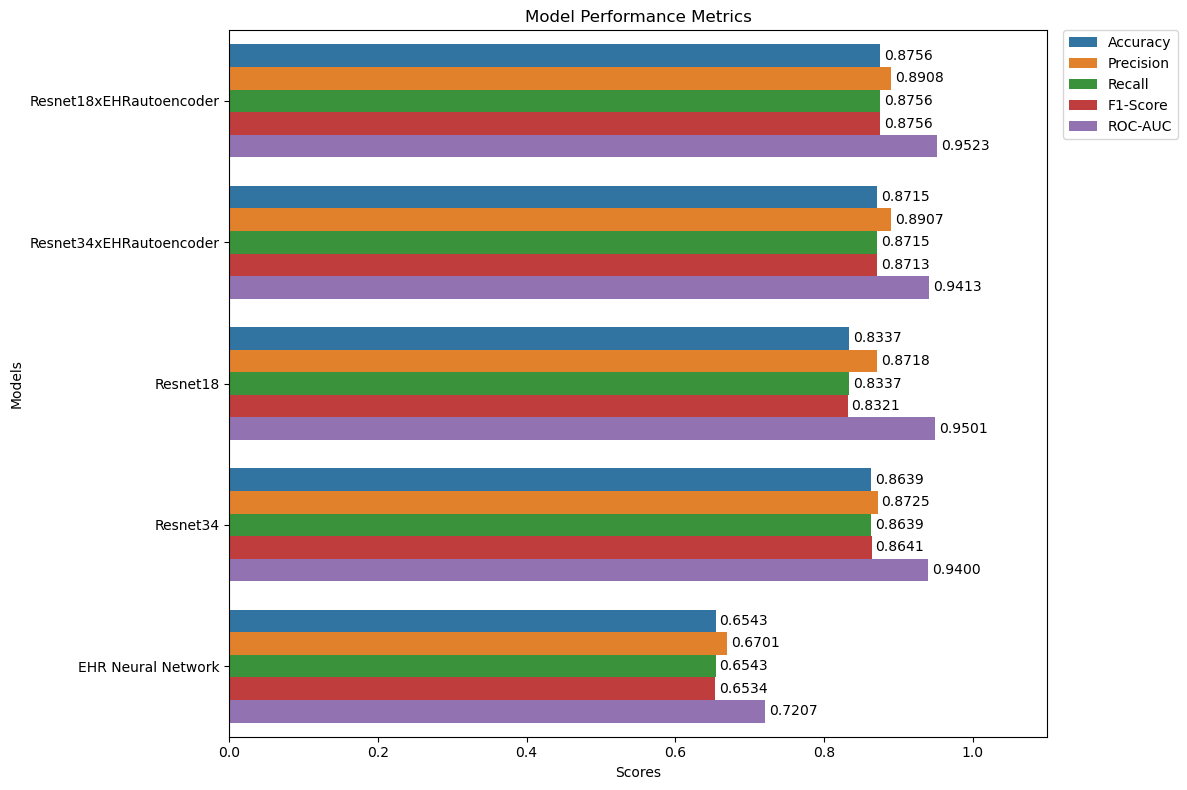

In [3]:
# 1. Your data


data = {
    'Models': ['Resnet18xEHRautoencoder','Resnet18xEHRautoencoder','Resnet18xEHRautoencoder','Resnet18xEHRautoencoder','Resnet18xEHRautoencoder',
               'Resnet34xEHRautoencoder','Resnet34xEHRautoencoder','Resnet34xEHRautoencoder','Resnet34xEHRautoencoder','Resnet34xEHRautoencoder',
               'Resnet18','Resnet18','Resnet18','Resnet18','Resnet18',
               'Resnet34','Resnet34','Resnet34','Resnet34','Resnet34',"EHR Neural Network","EHR Neural Network","EHR Neural Network","EHR Neural Network","EHR Neural Network"],
    'Metrics': ["Accuracy","Precision","Recall","F1-Score" ,"ROC-AUC","Accuracy","Precision","Recall","F1-Score" ,"ROC-AUC","Accuracy","Precision","Recall","F1-Score" ,"ROC-AUC"
                ,"Accuracy","Precision","Recall","F1-Score" ,"ROC-AUC","Accuracy","Precision","Recall","F1-Score" ,"ROC-AUC"],
    'Scores': [0.8756,0.8908,0.8756,0.8756,0.9523,
               0.8715,0.8907,0.8715,0.8713,0.9413,
               0.8337,0.8718,0.8337,0.8321,0.9501,
               0.8639,0.8725,0.8639,0.8641,0.9400,
               0.6543,0.6701,0.6543,0.6534,0.7207]
}

df_grouped = pd.DataFrame(data)
plt.figure(figsize=(12, 8)) # Adjusted figure size for horizontal layout

# 2. Create the horizontal grouped bar chart
#    Swap x and y arguments
ax = sns.barplot(data=df_grouped, x='Scores', y='Models', hue='Metrics', orient='h')

# --- Annotation logic updated for horizontal plot ---
for p in ax.patches:
    # Get the width of the bar (which is the value)
    width = p.get_width()
    if width == 0:  
        continue  # Skip annotation for zero-width bars
    # Add the text label to the right of the bar
    # 'width' is the x-coordinate
    # 'p.get_y() + p.get_height() / 2.' is the y-coordinate (center of the bar)
    ax.text(
        width + 0.005,  # The x-position (slight padding)
        p.get_y() + p.get_height() / 2., # The y-position (center of the bar)
        f'{width:.4f}', # The text to display
        ha='left',    # Horizontal alignment: left-align the text
        va='center'   # Vertical alignment: center the text
    )
# --- End of annotation logic ---

# 3. Add titles and labels for clarity (swapped)
plt.title('Model Performance Metrics')
plt.xlabel('Scores')
plt.ylabel('Models')
plt.xlim(0, 1.1) # Adjust x-axis limit to make space for text

# 4. Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# 5. Ensure everything fits
plt.tight_layout()

# 6. Show the plot
plt.show()

## Boxplots

In [ ]:
Cancer_positive34.loc[:,"Model"] = 'Resnet34xEHRautoencoder'
Cancer_positive34_new = Cancer_positive34[['age','Model']].copy()
Cancer_positive18.loc[:,"Model"] = 'Resnet18xEHRautoencoder'
Cancer_positive18_new = Cancer_positive18[['age','Model']].copy()

boxplot_dataset = pd.concat([Cancer_positive18_new,Cancer_positive34_new])
model_stats = boxplot_dataset.groupby('Model')['age'].describe()
plt.figure(figsize=(6, 6)) # Optional: adjusts the size of the plot
sns.boxplot(x='Model', y='age', data=boxplot_dataset)

# Add title and labels for clarity
plt.title('Distribution of Ages of TP Prediction of the two models')
plt.xlabel('Models')
plt.ylabel('Age')

# Show the plot
plt.show()
print("Boxplot Statistics:")
print(model_stats)


## TABLE DATA

In [ ]:
Lung_cancer_Mulimodal_table_data = pd.read_csv("Lung_Cancer_multimodal_patient_EHR.csv").iloc[:,1:-1].reset_index(drop=True)
Lung_cancer_Mulimodal_table_data

In [ ]:
Lung_cancer_Mulimodal_table_data.__len__()

In [ ]:
race_counts = Lung_cancer_Mulimodal_table_data.groupby('race')['age'].count().reset_index()
race_counts = race_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Mulimodal_table_data)

# 3. Calculate the percentage for each race.
race_counts['percentage'] = (race_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
race_counts['percentage'] = race_counts['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
race_counts


In [ ]:
gender_counts = Lung_cancer_Mulimodal_table_data.groupby('gender')['age'].count().reset_index()
gender_counts = gender_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Mulimodal_table_data)

# 3. Calculate the percentage for each race.
gender_counts['percentage'] = (gender_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
gender_counts['percentage'] = gender_counts['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
gender_counts

In [ ]:
smoke_count = Lung_cancer_Mulimodal_table_data.groupby('cigsmok')['age'].count().reset_index()
smoke_count = smoke_count.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Mulimodal_table_data)

# 3. Calculate the percentage for each race.
smoke_count['percentage'] = (smoke_count['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
smoke_count['percentage'] = smoke_count['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
smoke_count

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(Lung_cancer_Mulimodal_table_data['age'], bins=20, edgecolor='black')

plt.title('Histogram of NLST Patient Data')
plt.xlabel('Value')
plt.ylabel('Frequency')


plt.axvline(
    Lung_cancer_Mulimodal_table_data['age'].mean(),
    color='red',
    linestyle='dashed',
    linewidth=3,
    label=f'Mean: {Lung_cancer_Mulimodal_table_data['age'].mean():.4f}'
)
plt.legend()

In [ ]:
Lung_cancer_Training_table_data = pd.read_csv("Lung_Cancer_training_EHR.csv").iloc[:,1:-1].reset_index(drop=True)
Lung_cancer_Training_table_data

In [ ]:
Lung_cancer_Training_table_data.__len__()

In [ ]:
race_counts = Lung_cancer_Training_table_data.groupby('race')['age'].count().reset_index()
race_counts = race_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Training_table_data)

# 3. Calculate the percentage for each race.
race_counts['percentage'] = (race_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
race_counts['percentage'] = race_counts['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
race_counts


In [ ]:
gender_counts = Lung_cancer_Training_table_data.groupby('gender')['age'].count().reset_index()
gender_counts = gender_counts.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Training_table_data)

# 3. Calculate the percentage for each race.
gender_counts['percentage'] = (gender_counts['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
gender_counts['percentage'] = gender_counts['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
gender_counts

In [ ]:
smoke_count = Lung_cancer_Training_table_data.groupby('cigsmok')['age'].count().reset_index()
smoke_count = smoke_count.rename(columns={'age': '# count'})


# 2. Calculate the total number of records.
total_count = len(Lung_cancer_Training_table_data)

# 3. Calculate the percentage for each race.
smoke_count['percentage'] = (smoke_count['# count'] / total_count) * 100

# 4. Format the percentage to two decimal places and add a '%' sign.
smoke_count['percentage'] = smoke_count['percentage'].map('{:.2f}%'.format)

# Display the final table with race, count, and percentage.
print("Distribution of patients by race:")
smoke_count

In [ ]:
Lung_cancer_Mulimodal_table_data['age'].describe()